In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config
import os
import numpy as np

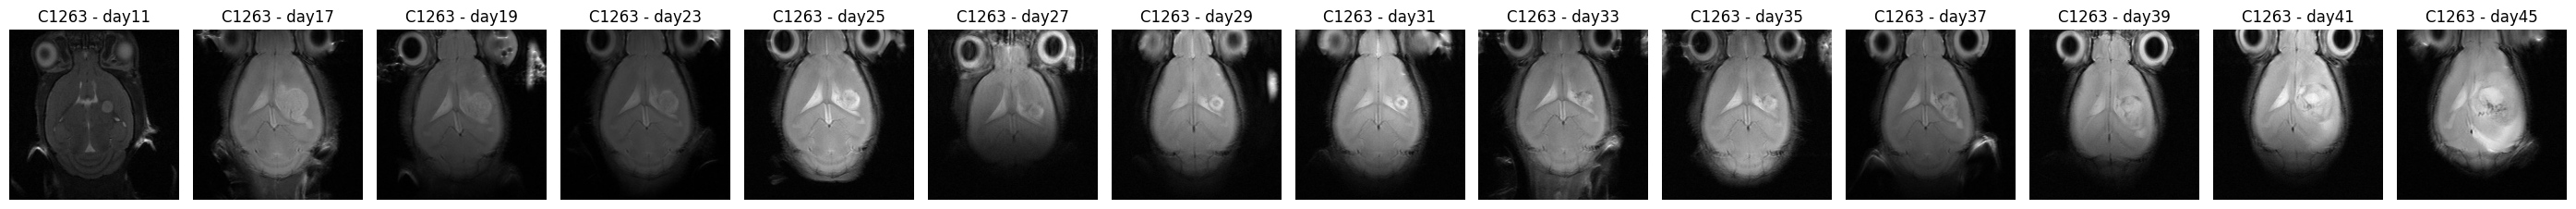

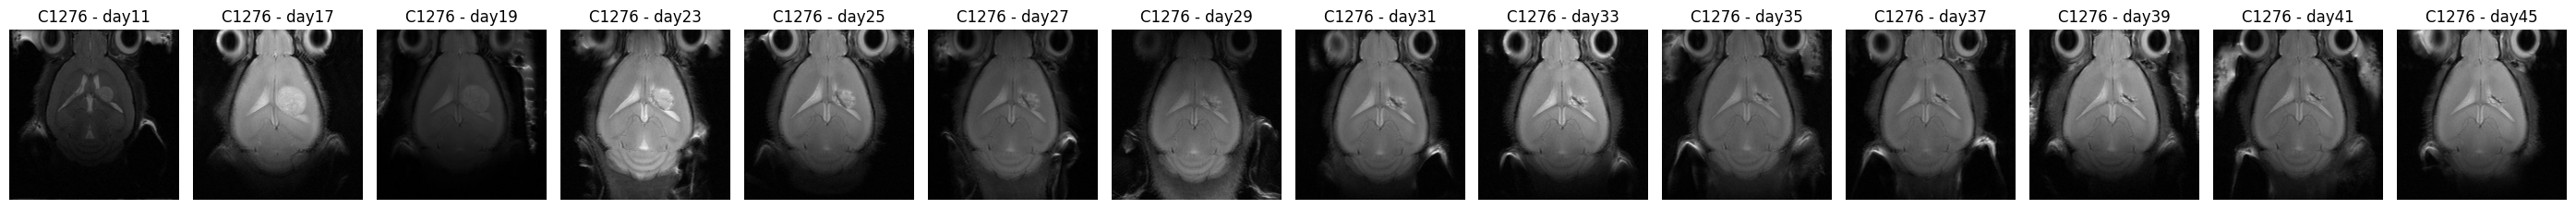

In [34]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np

def get_images(base_path):
    images = {}
    for root, _, files in os.walk(base_path):
        for file in files:
            if file == "image_s1.jpg":  # Filtra solo la imagen deseada
                day = os.path.basename(os.path.dirname(root))  # Extrae el día del path
                images[day] = os.path.join(root, file)
    return images

# Paths de los datasets
input_relapse_example = "input/dataset/IMS-TMS-TREATED-RELAPSING/C1263"
input_cured_example = "input/dataset/Cured mice/C1276"

# Obtener imágenes
relapse_images = get_images(input_relapse_example)
cured_images = get_images(input_cured_example)

# Obtener solo los días comunes
common_days = sorted(set(relapse_images.keys()) & set(cured_images.keys()), key=lambda x: int(x[3:]))

# Función para mostrar progresión solo en días comunes
def plot_progression(images, days, title):
    fig, axes = plt.subplots(1, len(days), figsize=(2 * len(days), 5))
    if len(days) == 1:
        axes = [axes]  # Asegurar que sea iterable si solo hay una imagen
    
    for ax, day in zip(axes, days):
        img_path = images[day]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB
        ax.imshow(img)
        ax.set_title(f"{title} - {day}")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

# Plotear progresión solo en días comunes para Relapse y Cured
plot_progression(relapse_images, common_days, "C1263")
plot_progression(cured_images, common_days, "C1276")


In [12]:
# Cargar el dataset
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)  # Reemplaza con tu ruta de archivo

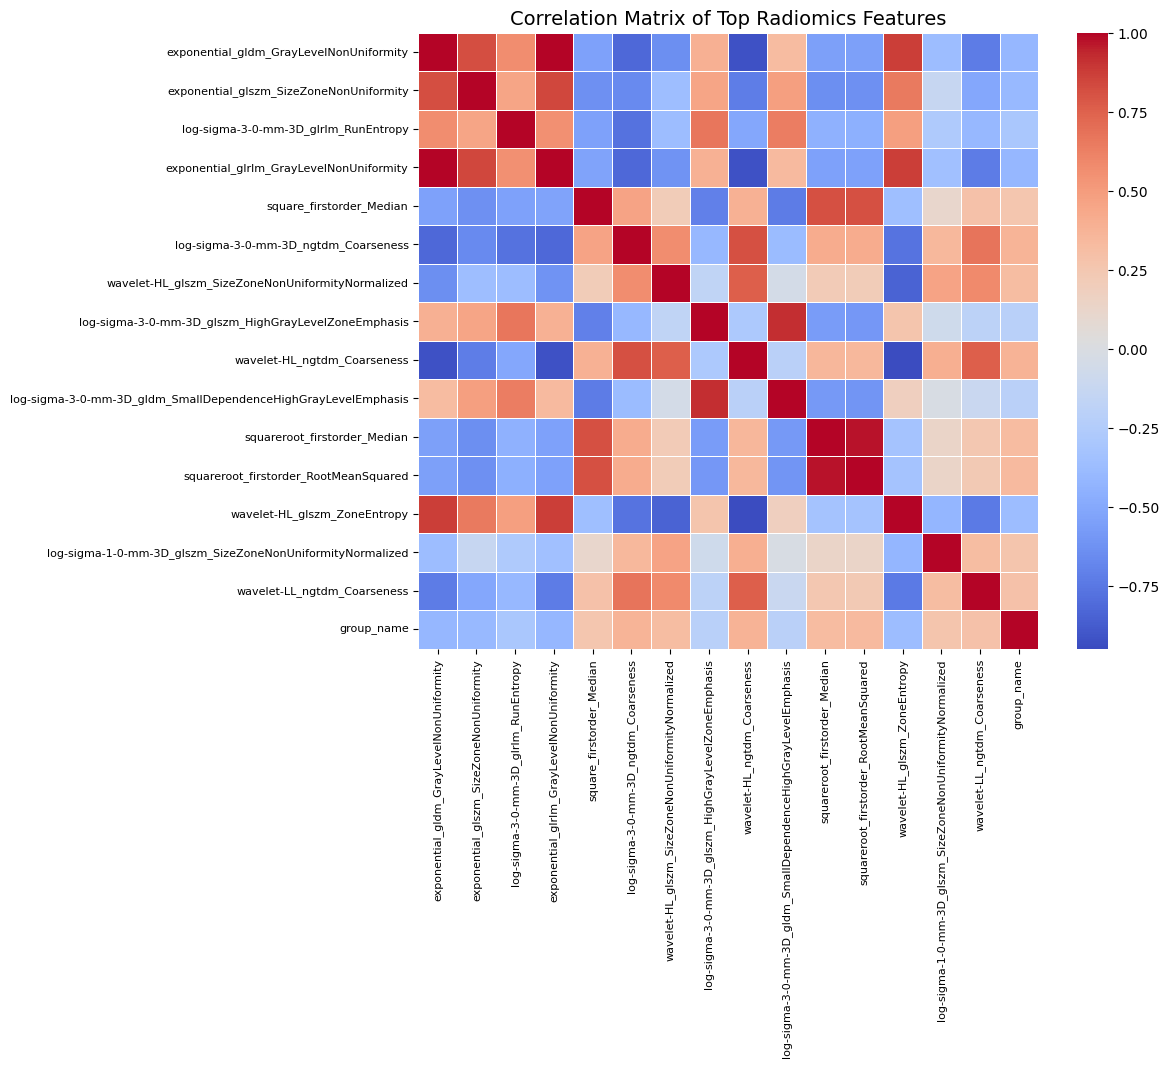

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la correlación entre todas las features
corr_matrix = df[features_list].corr(method='spearman')

# Ajustar el tamaño de la figura
plt.figure(figsize=(10, 8))  # Aumentar tamaño para mejor visualización

# Graficar con un heatmap
sns.heatmap(
    corr_matrix, 
    annot=False, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5,
)

# Mejorar la legibilidad de las etiquetas
plt.xticks(fontsize=8)  # Rotar y reducir fuente
plt.yticks(fontsize=8)  # Reducir fuente del eje Y
plt.title("Correlation Matrix of Top Radiomics Features", fontsize=14)  # Ajustar tamaño del título
plt.show()



📊 Fold 0 - Features: ['square_glszm_ZoneVariance', 'gradient_firstorder_10Percentile', 'log-sigma-1-0-mm-3D_ngtdm_Strength']


📊 Fold 1 - Features: ['wavelet-HL_glszm_SizeZoneNonUniformityNormalized', 'logarithm_firstorder_RootMeanSquared', 'log-sigma-1-0-mm-3D_glszm_ZoneEntropy']


📊 Fold 2 - Features: ['exponential_gldm_LargeDependenceLowGrayLevelEmphasis', 'log-sigma-1-0-mm-3D_glrlm_RunEntropy', 'wavelet-HL_glszm_SizeZoneNonUniformityNormalized']


📊 Fold 3 - Features: ['log-sigma-3-0-mm-3D_ngtdm_Coarseness', 'wavelet-HH_firstorder_Entropy', 'squareroot_firstorder_RootMeanSquared']



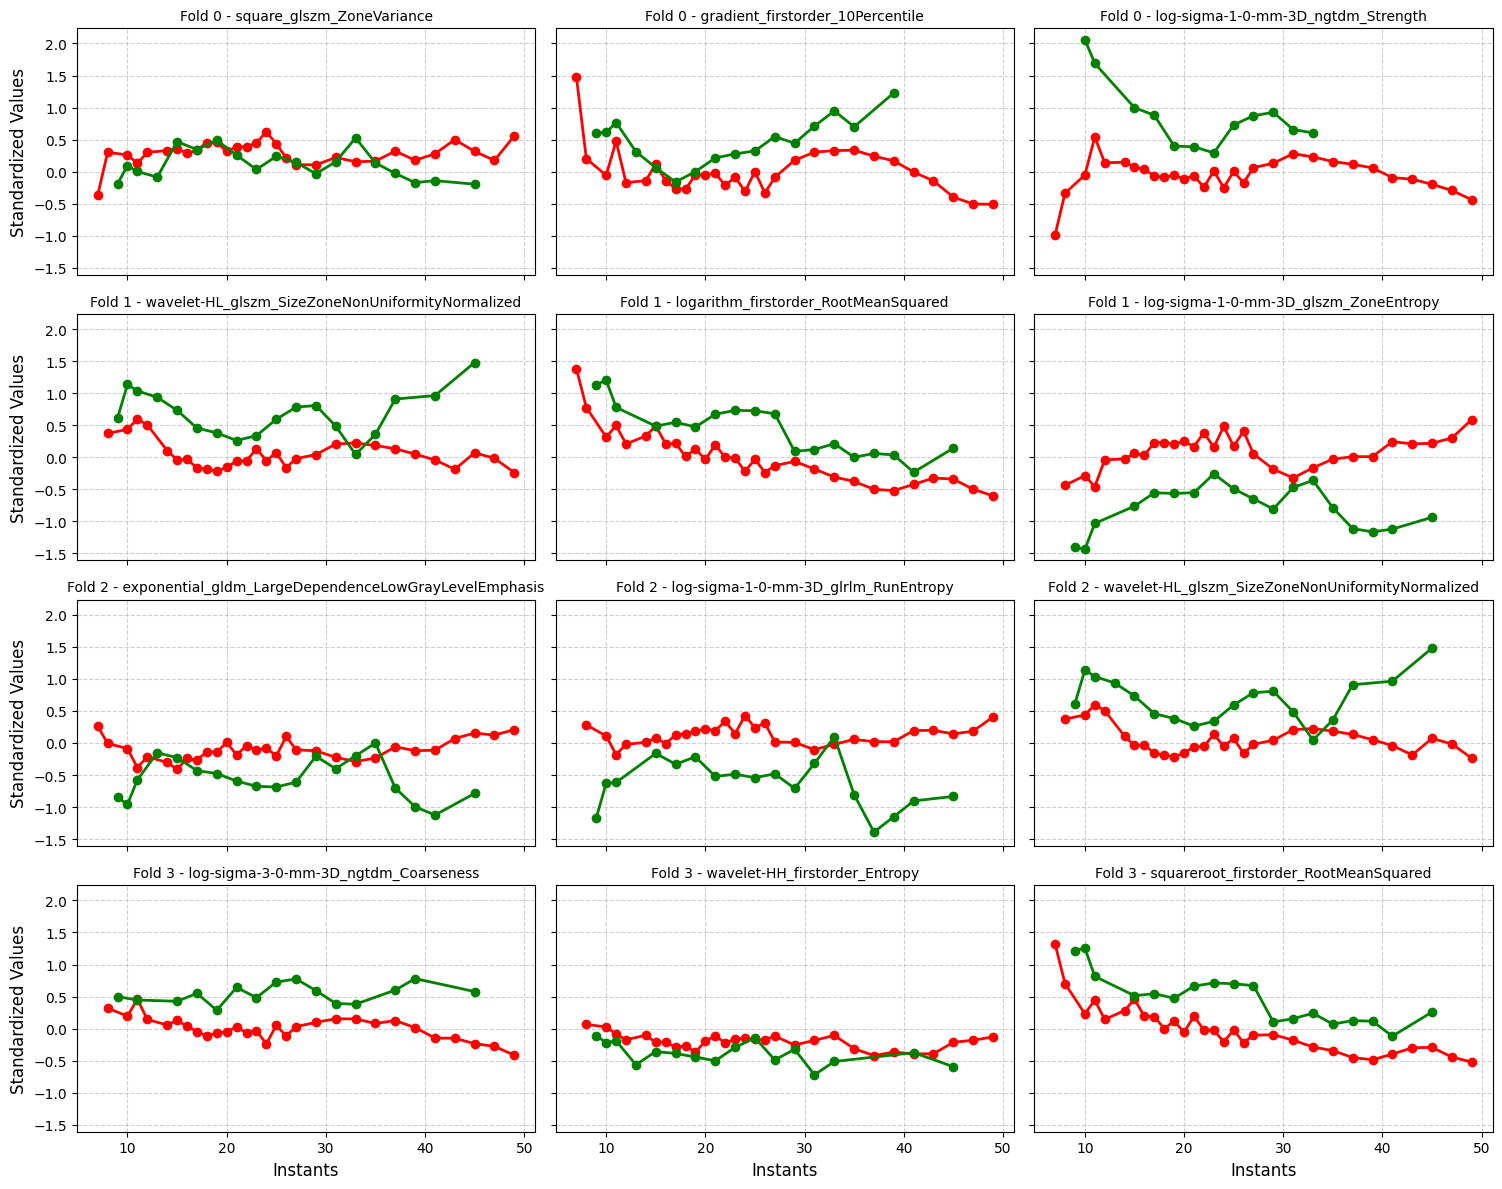

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# Paths a los CSV de cada fold
fold_paths = {
    0: "output/expanding_window_split/fold_0/top_features.csv",
    1: "output/expanding_window_split/fold_1/top_features.csv",
    2: "output/expanding_window_split/fold_2/top_features.csv",
    3: "output/expanding_window_split/fold_3/top_features.csv",
}

# Cargar las tres características más importantes de cada fold
features_per_fold = {fold: pd.read_csv(path)["feature"].head(3).tolist() for fold, path in fold_paths.items()}

# Definir colores por grupo
colors = {1: 'green', 0: 'red'}

# Crear figura y ejes con subplots (4 filas = folds, 3 columnas = features)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12), sharex=True, sharey=True)

# Iterar sobre cada fold
for i, (fold, features) in enumerate(features_per_fold.items()):
    print(f"\n📊 Fold {fold} - Features: {features}\n")
    
    # Estandarizar solo las características de este fold
    scaler = RobustScaler()
    df[features] = scaler.fit_transform(df[features])

    # Iterar sobre cada característica del fold
    for j, feature in enumerate(features):
        ax = axes[i, j]  # Seleccionar el subplot correspondiente

        # Filtrar outliers
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

        # Agrupar por grupo y día de estudio
        df_grouped = df_clean.groupby(["group_name", "day_of_study"])[feature].agg(['mean']).reset_index()

        # Aplicar suavizado exponencial
        df_grouped["smoothed_mean"] = df_grouped.groupby("group_name")["mean"].transform(lambda x: x.ewm(span=3, adjust=False).mean())

        # Graficar cada grupo
        for group in df_grouped["group_name"].unique():
            subset = df_grouped[df_grouped["group_name"] == group]
            ax.plot(subset["day_of_study"], subset["smoothed_mean"], '-o', 
                    linewidth=2, markersize=6, color=colors[group], label=f"Group {group}")

        # Etiquetas solo en bordes
        if i == 3:  # Última fila
            ax.set_xlabel("Instants", fontsize=12)
        if j == 0:  # Primera columna
            ax.set_ylabel("Standardized Values", fontsize=12)

        ax.set_title(f"Fold {fold} - {feature}", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()


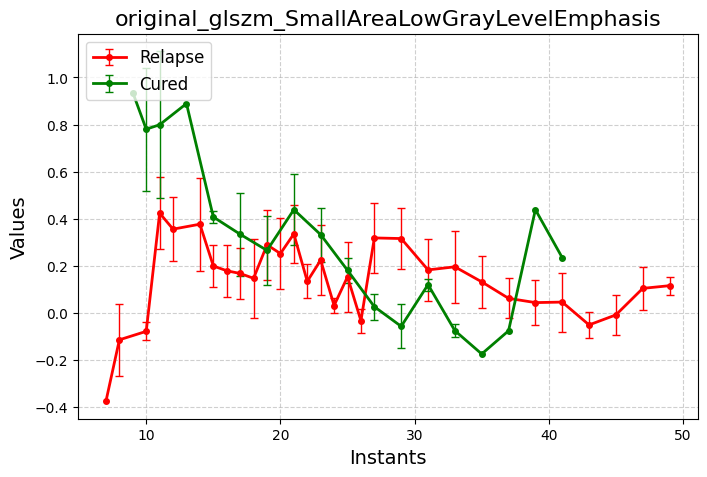

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# Lista de características a graficar
features_list = [
    "original_glszm_SmallAreaLowGrayLevelEmphasis",
]

# Definir función para eliminar outliers usando IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Definir colores para los grupos
colors = {1: ('green', 'Cured'), 0: ('red', 'Relapse')}

# Iterar sobre cada feature y crear gráficos independientes
for feature in features_list:
    plt.figure(figsize=(8, 5))  # Crear nueva figura para cada gráfico

    # Estandarizar la característica
    scaler = RobustScaler()
    df[feature] = scaler.fit_transform(df[[feature]])

    # Aplicar la eliminación de outliers
    df_clean = remove_outliers(df, feature)

    # Agrupar por día de estudio y grupo
    df_grouped = df_clean.groupby(["group_name", "day_of_study"])[feature].agg(['mean', 'std']).reset_index()

    # Aplicar suavizado exponencial
    df_grouped["smoothed_mean"] = df_grouped.groupby("group_name")["mean"].transform(lambda x: x.ewm(span=3, adjust=False).mean())

    # Reducir el tamaño de las barras de error
    df_grouped["scaled_std"] = df_grouped["std"] * 0.2

    # Graficar cada grupo
    for group in df_grouped["group_name"].unique():
        subset = df_grouped[df_grouped["group_name"] == group]
        plt.errorbar(subset["day_of_study"], subset["smoothed_mean"], yerr=subset["scaled_std"],
                     fmt='-o', capsize=3, linewidth=2, elinewidth=1, markersize=4,
                     color=colors[group][0], label=colors[group][1])

    # Personalizar gráfico
    plt.xlabel("Instants", fontsize=14)
    plt.ylabel("Values", fontsize=14)
    plt.title(feature, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="upper left", fontsize=12)

    # Mostrar gráfico actual antes de pasar al siguiente
    plt.show()

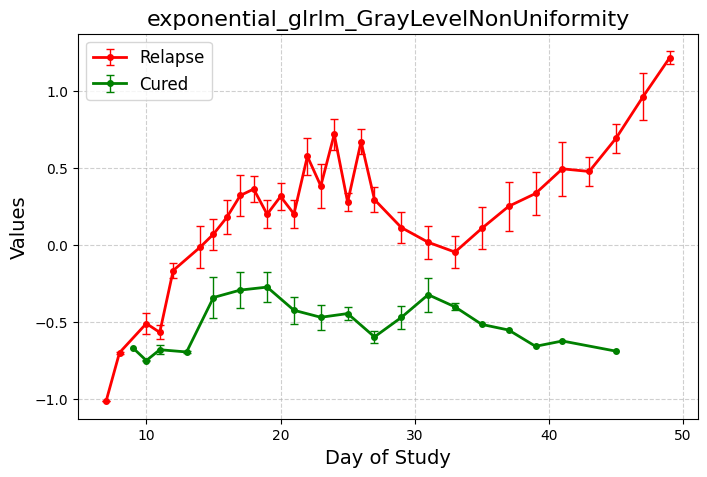

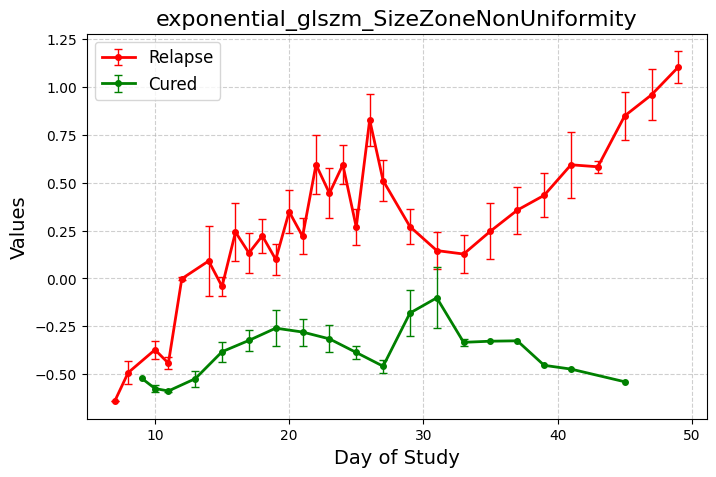

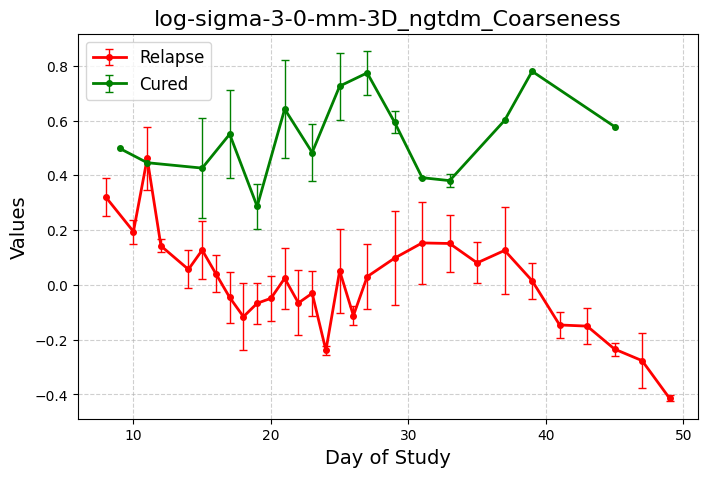

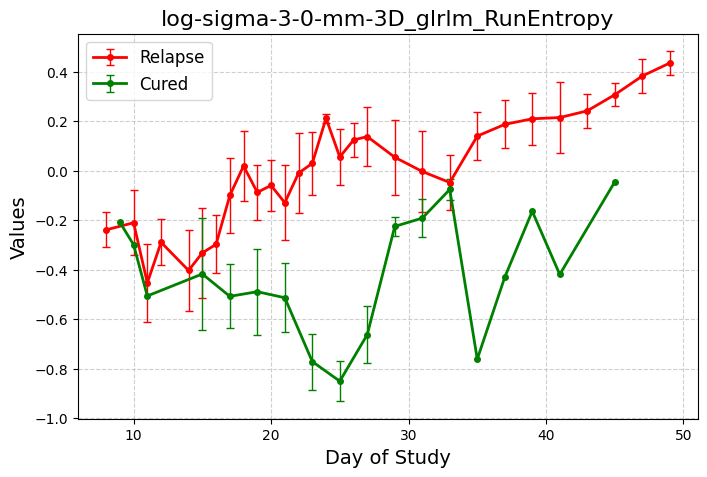

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# Lista de características a graficar
features_list = [
    "exponential_glrlm_GrayLevelNonUniformity",
    "exponential_glszm_SizeZoneNonUniformity",
    "log-sigma-3-0-mm-3D_ngtdm_Coarseness",
    "log-sigma-3-0-mm-3D_glrlm_RunEntropy"
]

# Definir función para eliminar outliers usando IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Definir colores para los grupos
colors = {1: ('green', 'Cured'), 0: ('red', 'Relapse')}

# Iterar sobre cada feature y crear gráficos independientes
for feature in features_list:
    plt.figure(figsize=(8, 5))  # Crear nueva figura para cada gráfico

    # Estandarizar la característica
    scaler = RobustScaler()
    df[feature] = scaler.fit_transform(df[[feature]])

    # Aplicar la eliminación de outliers
    df_clean = remove_outliers(df, feature)

    # Agrupar por día de estudio y grupo
    df_grouped = df_clean.groupby(["group_name", "day_of_study"])[feature].agg(['mean', 'std']).reset_index()

    # Aplicar suavizado exponencial
    df_grouped["smoothed_mean"] = df_grouped.groupby("group_name")["mean"].transform(lambda x: x.ewm(span=3, adjust=False).mean())

    # Reducir el tamaño de las barras de error
    df_grouped["scaled_std"] = df_grouped["std"] * 0.2

    # Graficar cada grupo
    for group in df_grouped["group_name"].unique():
        subset = df_grouped[df_grouped["group_name"] == group]
        plt.errorbar(subset["day_of_study"], subset["smoothed_mean"], yerr=subset["scaled_std"],
                     fmt='-o', capsize=3, linewidth=2, elinewidth=1, markersize=4,
                     color=colors[group][0], label=colors[group][1])

    # Personalizar gráfico
    plt.xlabel("Day of Study", fontsize=14)
    plt.ylabel("Values", fontsize=14)
    plt.title(feature, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="upper left", fontsize=12)

    # Mostrar gráfico actual antes de pasar al siguiente
    plt.show()




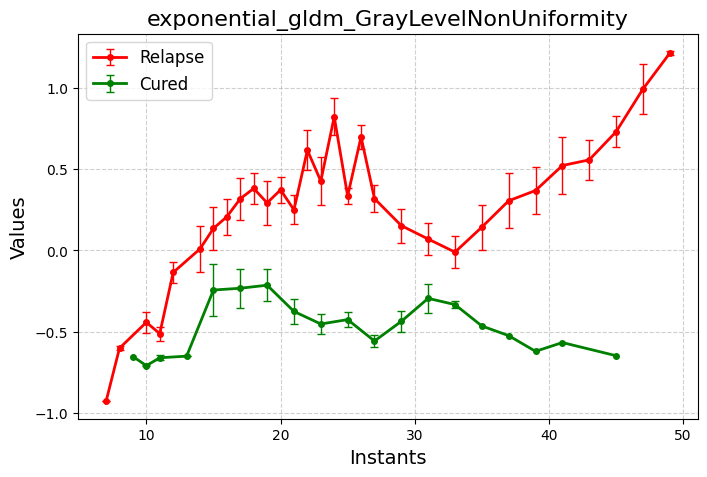

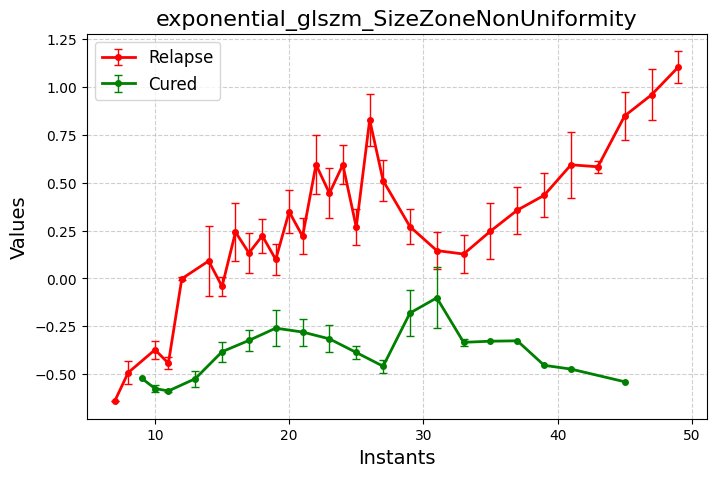

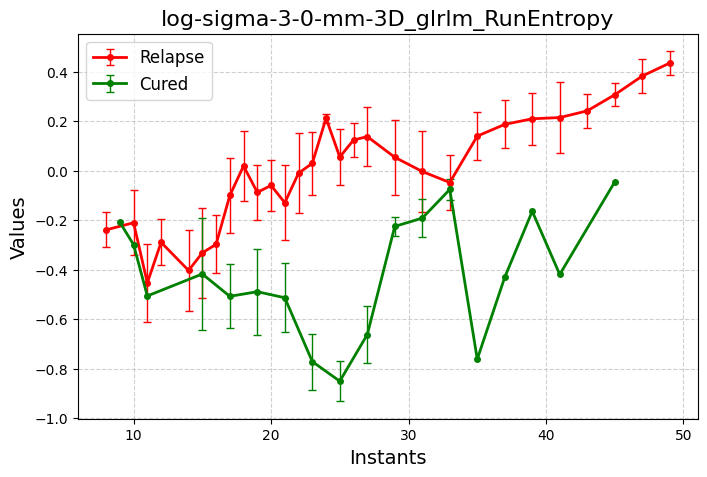

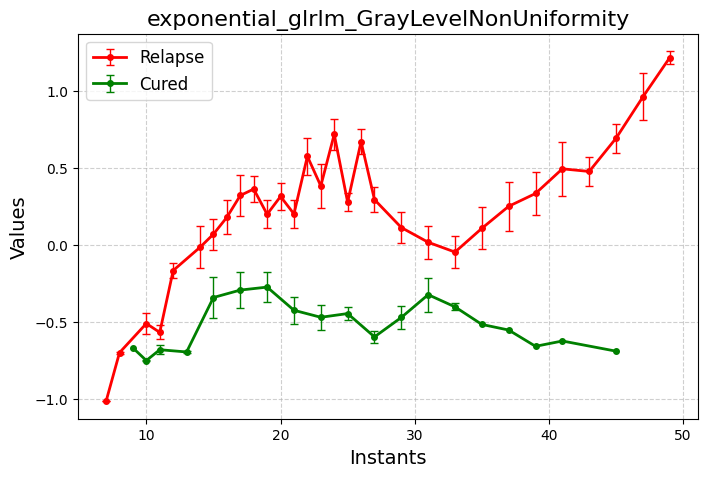

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# Lista de características a graficar
features_list = [
    "exponential_gldm_GrayLevelNonUniformity",
    "exponential_glszm_SizeZoneNonUniformity",
    "log-sigma-3-0-mm-3D_glrlm_RunEntropy",
    "exponential_glrlm_GrayLevelNonUniformity",
]

# Definir función para eliminar outliers usando IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Definir colores para los grupos
colors = {1: ('green', 'Cured'), 0: ('red', 'Relapse')}

# Iterar sobre cada feature y crear gráficos independientes
for feature in features_list:
    plt.figure(figsize=(8, 5))  # Crear nueva figura para cada gráfico

    # Estandarizar la característica
    scaler = RobustScaler()
    df[feature] = scaler.fit_transform(df[[feature]])

    # Aplicar la eliminación de outliers
    df_clean = remove_outliers(df, feature)

    # Agrupar por día de estudio y grupo
    df_grouped = df_clean.groupby(["group_name", "day_of_study"])[feature].agg(['mean', 'std']).reset_index()

    # Aplicar suavizado exponencial
    df_grouped["smoothed_mean"] = df_grouped.groupby("group_name")["mean"].transform(lambda x: x.ewm(span=3, adjust=False).mean())

    # Reducir el tamaño de las barras de error
    df_grouped["scaled_std"] = df_grouped["std"] * 0.2

    # Graficar cada grupo
    for group in df_grouped["group_name"].unique():
        subset = df_grouped[df_grouped["group_name"] == group]
        plt.errorbar(subset["day_of_study"], subset["smoothed_mean"], yerr=subset["scaled_std"],
                     fmt='-o', capsize=3, linewidth=2, elinewidth=1, markersize=4,
                     color=colors[group][0], label=colors[group][1])

    # Personalizar gráfico
    plt.xlabel("Instants", fontsize=14)
    plt.ylabel("Values", fontsize=14)
    plt.title(feature, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="upper left", fontsize=12)

    # Mostrar gráfico actual antes de pasar al siguiente
    plt.show()


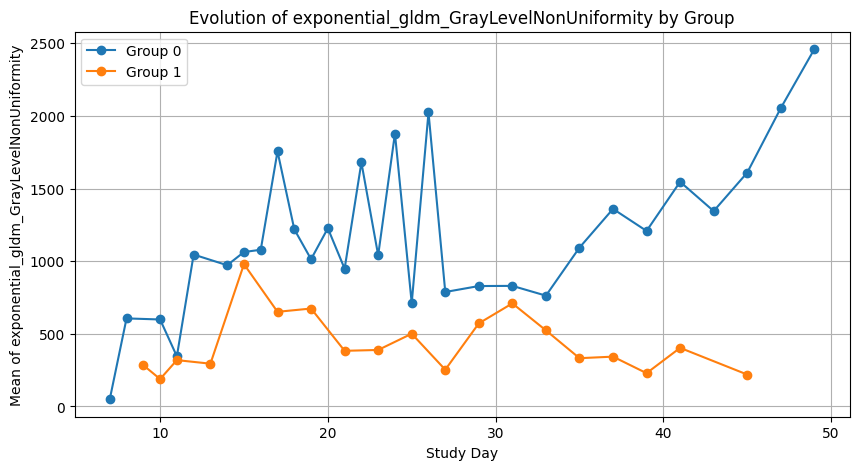

In [3]:
# Calculate the mean per day for each group
df_grouped = df.groupby(["group_name", "day_of_study"])["exponential_gldm_GrayLevelNonUniformity"].mean().reset_index()
# "original_firstorder_TotalEnergy"

# Create the plot
plt.figure(figsize=(10, 5))

for group in df_grouped["group_name"].unique():
    subset = df_grouped[df_grouped["group_name"] == group]
    plt.plot(subset["day_of_study"], subset["exponential_gldm_GrayLevelNonUniformity"], marker='o', label=f'Group {group}')

# Customize the plot
plt.xlabel("Study Day")
plt.ylabel("Mean of exponential_gldm_GrayLevelNonUniformity")
plt.title("Evolution of exponential_gldm_GrayLevelNonUniformity by Group")
plt.legend()
plt.grid(True)
plt.show()

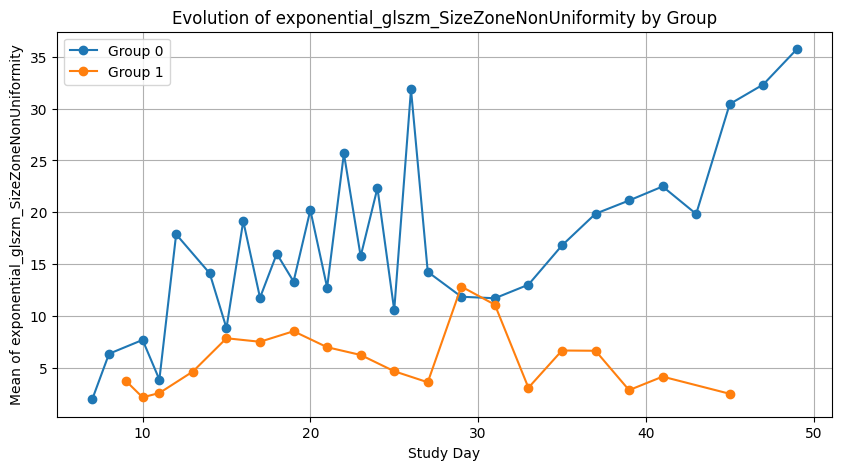

In [ ]:
# Calculate the mean per day for each group
df_grouped = df.groupby(["group_name", "day_of_study"])["exponential_glszm_SizeZoneNonUniformity"].mean().reset_index()
# "original_firstorder_TotalEnergy"

# Create the plot
plt.figure(figsize=(10, 5))

for group in df_grouped["group_name"].unique():
    subset = df_grouped[df_grouped["group_name"] == group]
    plt.plot(subset["day_of_study"], subset["exponential_glszm_SizeZoneNonUniformity"], marker='o', label=f'Group {group}')

# Customize the plot
plt.xlabel("Study Day")
plt.ylabel("Mean of exponential_glszm_SizeZoneNonUniformity")
plt.title("Evolution of exponential_glszm_SizeZoneNonUniformity by Group")
plt.legend()
plt.grid(True)
plt.show()


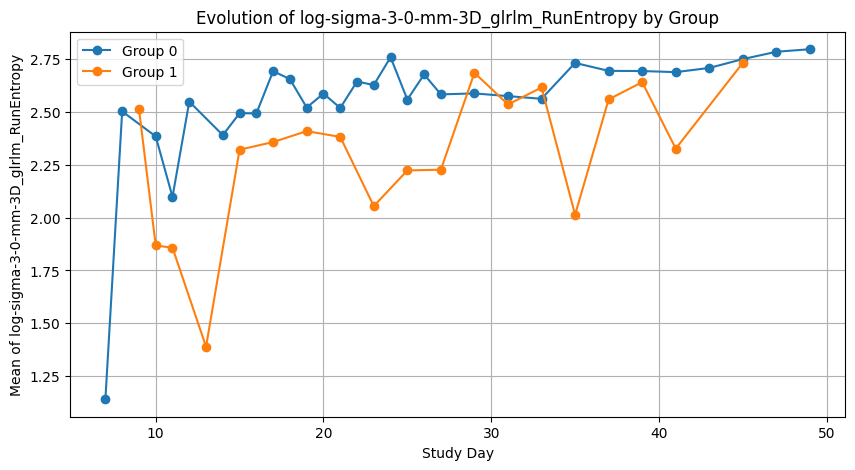

In [6]:
# Calculate the mean per day for each group
df_grouped = df.groupby(["group_name", "day_of_study"])["log-sigma-3-0-mm-3D_glrlm_RunEntropy"].mean().reset_index()
# "original_firstorder_TotalEnergy"

# Create the plot
plt.figure(figsize=(10, 5))

for group in df_grouped["group_name"].unique():
    subset = df_grouped[df_grouped["group_name"] == group]
    plt.plot(subset["day_of_study"], subset["log-sigma-3-0-mm-3D_glrlm_RunEntropy"], marker='o', label=f'Group {group}')

# Customize the plot
plt.xlabel("Study Day")
plt.ylabel("Mean of log-sigma-3-0-mm-3D_glrlm_RunEntropy")
plt.title("Evolution of log-sigma-3-0-mm-3D_glrlm_RunEntropy by Group")
plt.legend()
plt.grid(True)
plt.show()


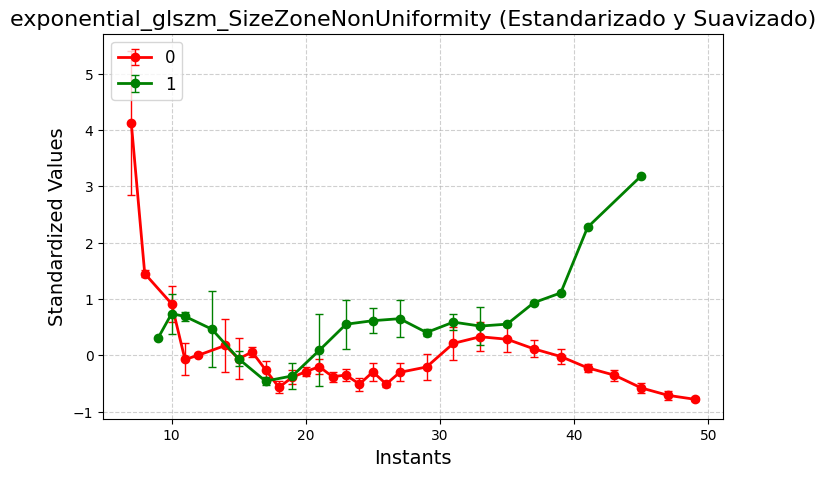

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Estandarizar la columna antes de eliminar outliers
scaler = StandardScaler()
df_clean = df.copy()
df_clean["gradient_firstorder_10Percentile"] = scaler.fit_transform(df[["gradient_firstorder_10Percentile"]])

# Definir función para eliminar outliers usando IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)  # Primer cuartil (Q1)
    Q3 = df[column].quantile(0.75)  # Tercer cuartil (Q3)
    IQR = Q3 - Q1  # Rango intercuartílico
    lower_bound = Q1 - 1.5 * IQR  # Límite inferior
    upper_bound = Q3 + 1.5 * IQR  # Límite superior
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]  # Filtrar

# Aplicar la eliminación de outliers
# df_clean = remove_outliers(df_clean, "gradient_firstorder_10Percentile")

# Calcular la media y desviación estándar sin outliers
df_grouped = df_clean.groupby(["group_name", "day_of_study"])["gradient_firstorder_10Percentile"].agg(['mean', 'std']).reset_index()

# Aplicar una media móvil con ventana de 3
df_grouped["smoothed_mean"] = df_grouped.groupby("group_name")["mean"].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Reducir el tamaño de las barras de error
df_grouped["scaled_std"] = df_grouped["std"] * 0.3  # Puedes ajustar este factor

# Crear la gráfica
plt.figure(figsize=(8, 5))

# Definir colores y etiquetas
colors = {1: 'green', 0: 'red'}

for group in df_grouped["group_name"].unique():
    subset = df_grouped[df_grouped["group_name"] == group]
    
    # Graficar la media suavizada con barras de error reducidas
    plt.errorbar(subset["day_of_study"], subset["smoothed_mean"], yerr=subset["scaled_std"], 
                 fmt='-o', capsize=3, linewidth=2, elinewidth=1, markersize=6, 
                 color=colors[group], label=group)

# Personalizar la gráfica
plt.xlabel("Instants", fontsize=14)
plt.ylabel("Standardized Values", fontsize=14)
plt.title("exponential_glszm_SizeZoneNonUniformity (Estandarizado y Suavizado)", fontsize=16)
plt.legend(loc="upper left", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar gráfica
plt.show()


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Apply standard scaling to the dataset
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)  # Reemplaza con tu ruta de archivo

# Seleccionar las columnas a escalar
columns = ["exponential_gldm_GrayLevelNonUniformity", "exponential_glszm_SizeZoneNonUniformity", "log-sigma-3-0-mm-3D_glrlm_RunEntropy"]

# Crear el objeto StandardScaler
scaler = StandardScaler()

# Escalar las columnas seleccionadas
df = scaler.fit_transform(df[columns])

# Definir función para eliminar outliers usando IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)  # Primer cuartil (Q1)
    Q3 = df[column].quantile(0.75)  # Tercer cuartil (Q3)
    IQR = Q3 - Q1  # Rango intercuartílico
    lower_bound = Q1 - 1.5 * IQR  # Límite inferior
    upper_bound = Q3 + 1.5 * IQR  # Límite superior
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]  # Filtrar

# Aplicar la eliminación de outliers a la columna que graficaremos
df_clean = remove_outliers(df, "exponential_glszm_SizeZoneNonUniformity")

# Calcular la media y desviación estándar sin outliers
df_grouped = df_clean.groupby(["group_name", "day_of_study"])["exponential_glszm_SizeZoneNonUniformity"].agg(['mean', 'std']).reset_index()

# Crear la gráfica
plt.figure(figsize=(8, 5))

# Definir colores y etiquetas
colors = {1: 'green', 0: 'red'}

for group in df_grouped["group_name"].unique():
    subset = df_grouped[df_grouped["group_name"] == group]
    
    # Graficar la media con barras de error (desviación estándar)
    plt.errorbar(subset["day_of_study"], subset["mean"], yerr=subset["std"], 
                 fmt='-o', capsize=3, linewidth=2, elinewidth=1, markersize=6, 
                 color=colors[group], label=group)

# Personalizar la gráfica
plt.xlabel("Instants", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.title("exponential_glszm_SizeZoneNonUniformity (Sin Outliers)", fontsize=16)
plt.legend(loc="upper left", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar gráfica
plt.show()



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

['log-sigma-3-0-mm-3D_ngtdm_Coarseness', 'log-sigma-3-0-mm-3D_gldm_SmallDependenceHighGrayLevelEmphasis', 'squareroot_firstorder_Median', 'log-sigma-3-0-mm-3D_glrlm_RunLengthNonUniformityNormalized', 'wavelet-HH_glcm_SumSquares', 'log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized', 'log-sigma-1-0-mm-3D_gldm_DependenceNonUniformityNormalized', 'square_ngtdm_Coarseness', 'wavelet-LH_glrlm_GrayLevelNonUniformityNormalized', 'original_glszm_SmallAreaEmphasis', 'wavelet-HH_glszm_SmallAreaLowGrayLevelEmphasis', 'square_glrlm_RunLengthNonUniformityNormalized', 'log-sigma-2-0-mm-3D_firstorder_Skewness', 'original_ngtdm_Strength', 'wavelet-HH_glszm_SmallAreaEmphasis', 'wavelet-HH_firstorder_Skewness', 'exponential_glrlm_RunLengthNonUniformityNormalized', 'wavelet-LH_firstorder_90Percentile', 'wavelet-HL_firstorder_90Percentile']


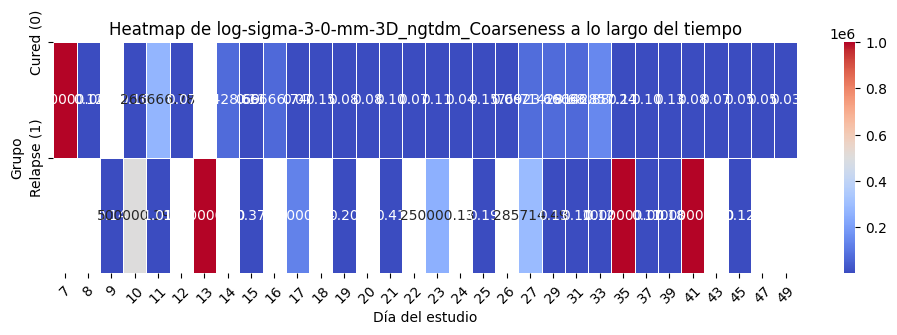

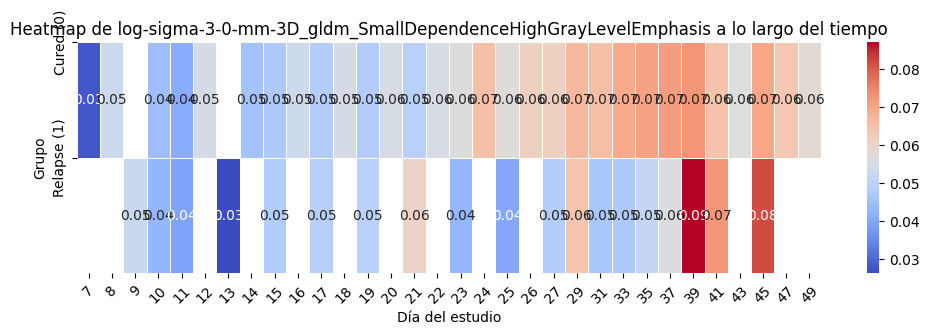

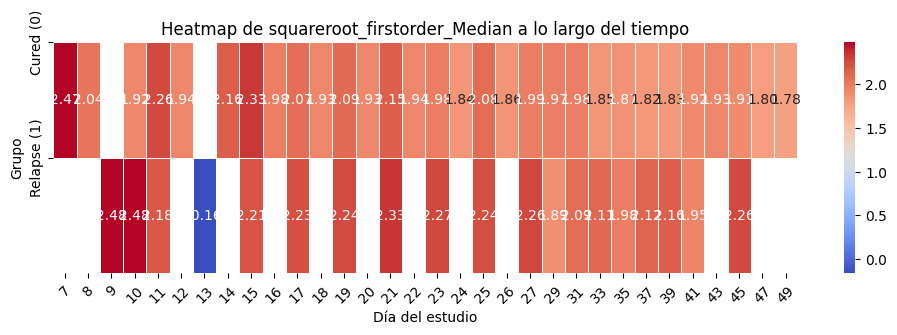

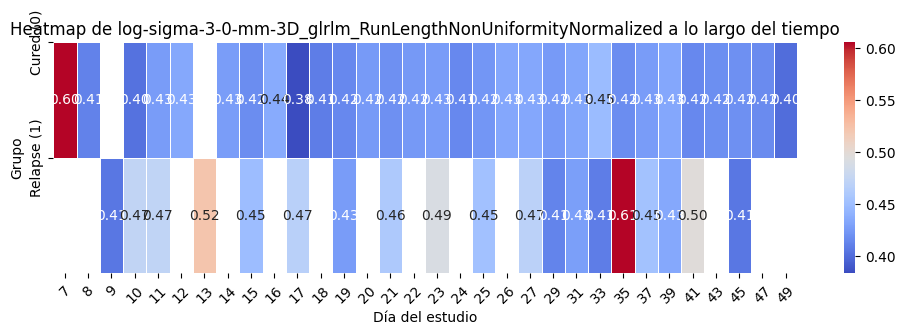

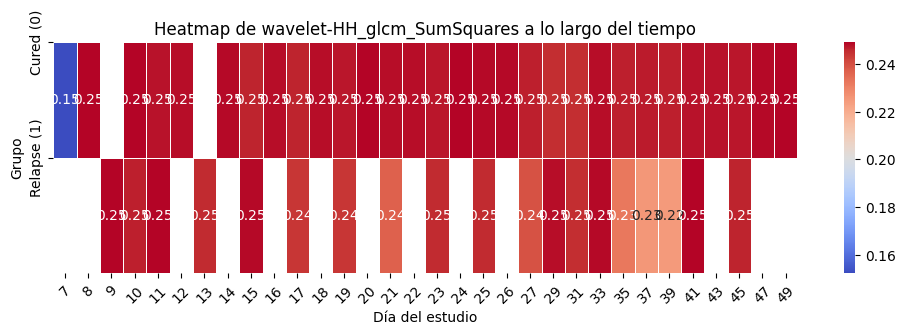

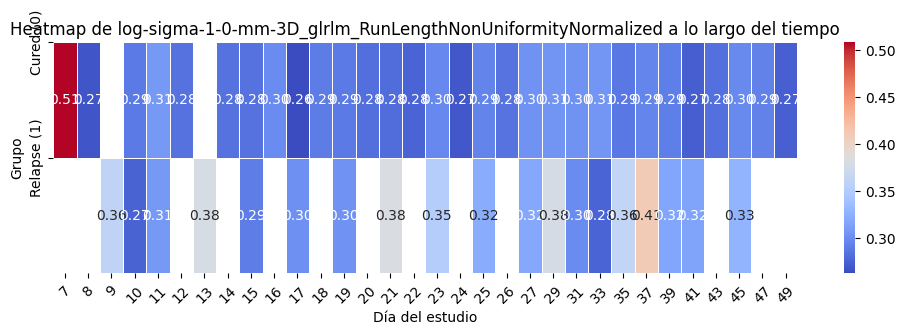

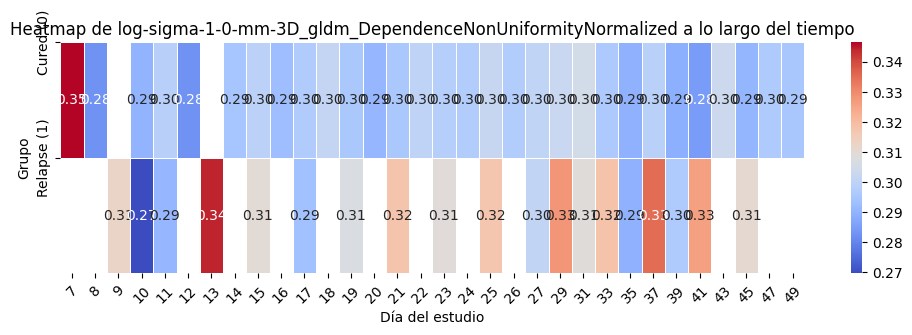

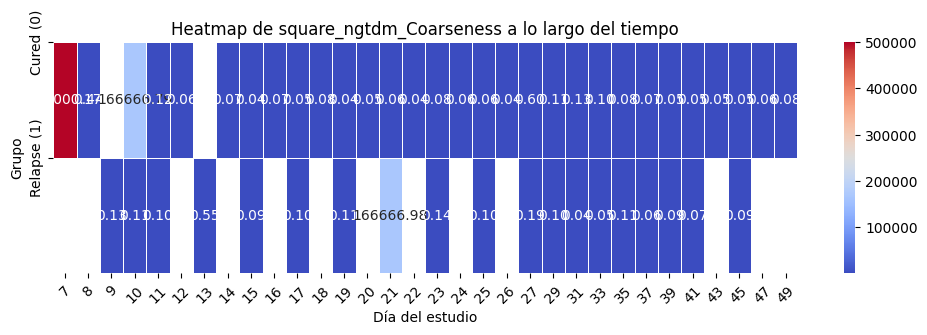

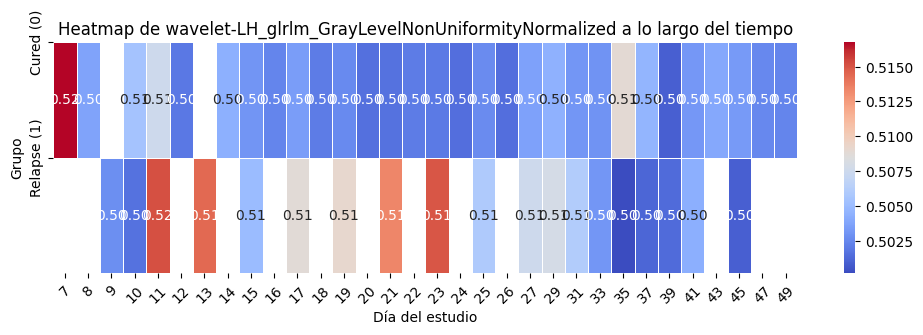

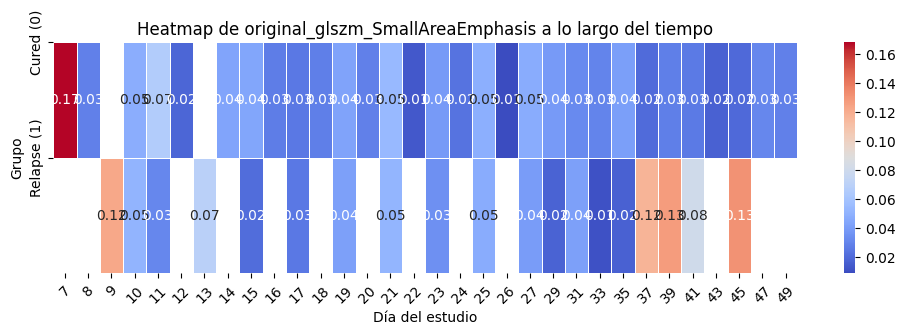

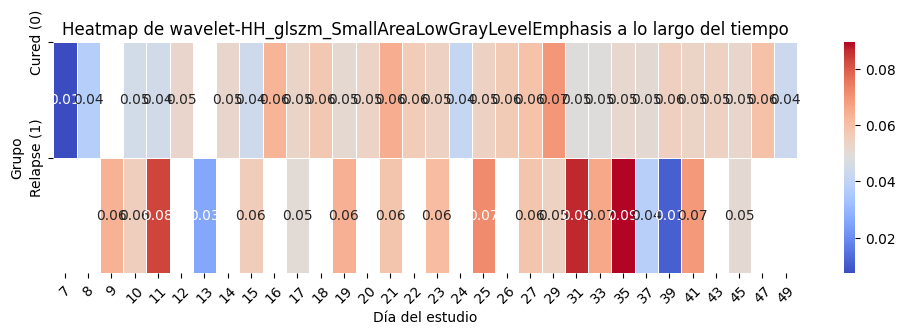

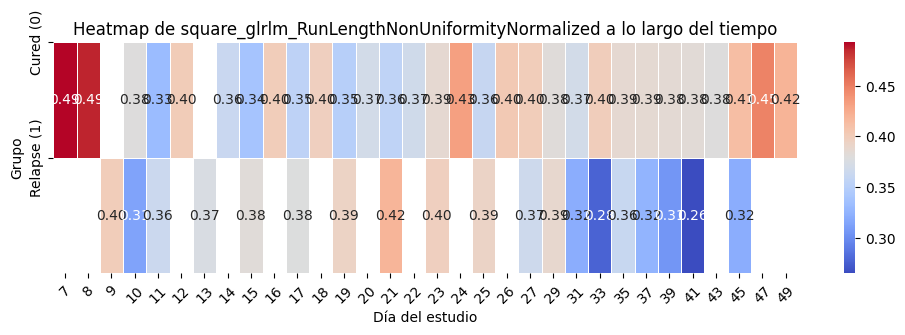

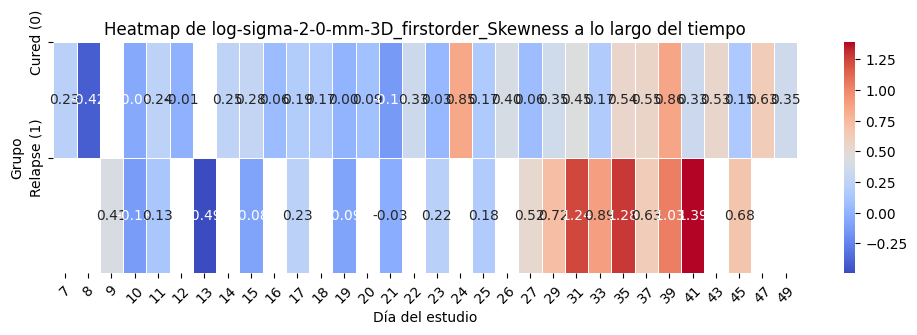

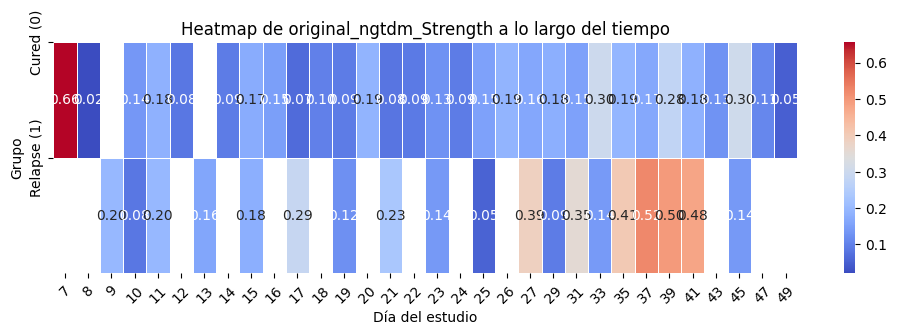

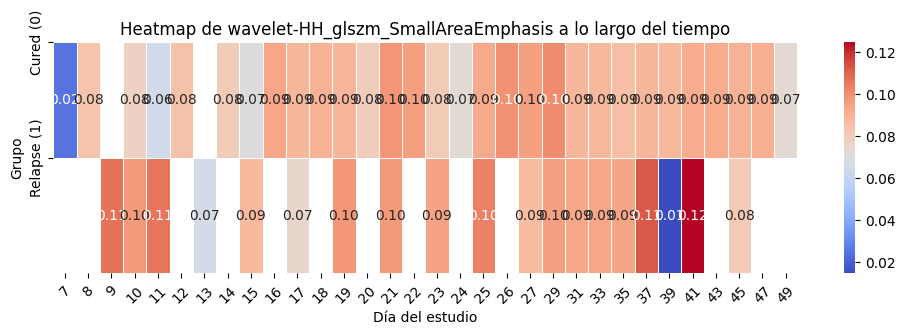

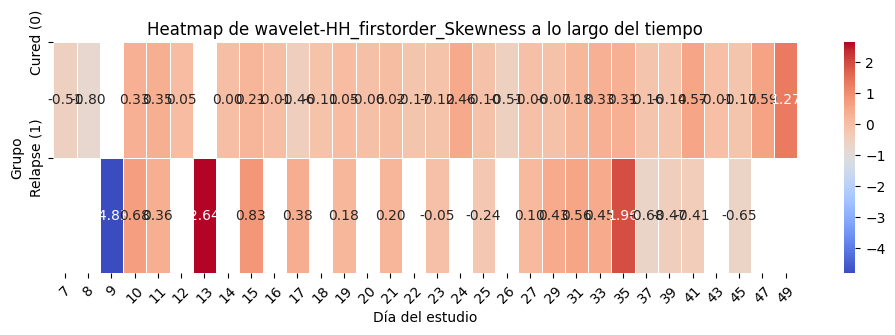

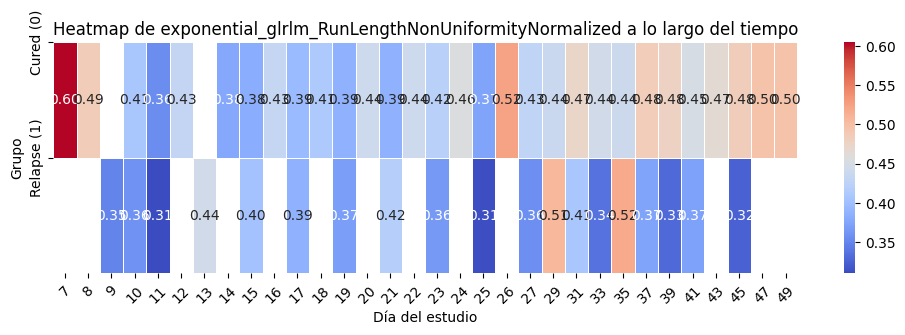

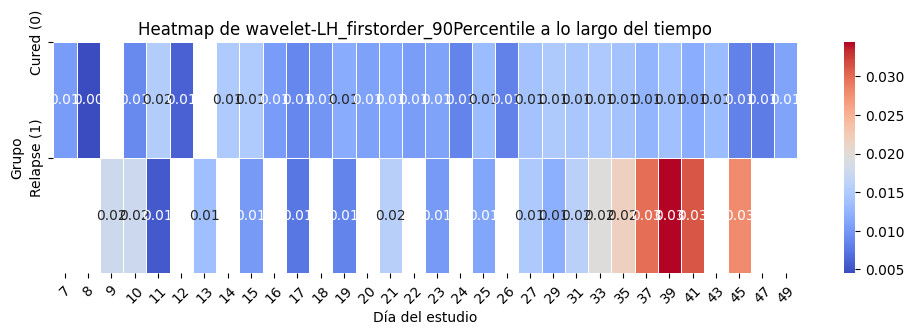

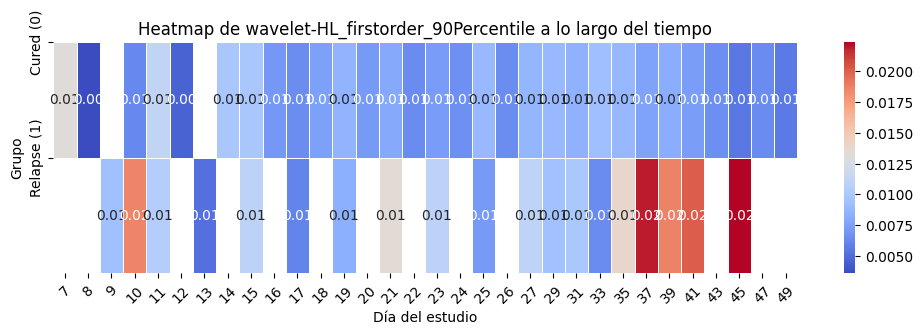

In [ ]:


# Cargar las características seleccionadas
features_csv = pd.read_csv("output/grouped_combinations_split_with_sampling/top_features/consistent_features.csv")
selected_features = features_csv["feature"].tolist()
print(selected_features)

# Filtrar solo las columnas necesarias
selected_columns = ["group_name", "day_of_study"] + selected_features
df_filtered = df[selected_columns]

# Agrupar por grupo y día de estudio, tomando la media
df_grouped = df_filtered.groupby(["group_name", "day_of_study"]).mean().reset_index()

# Graficar la evolución temporal de cada feature con heatmap
for feature in selected_features:
    if feature in df_grouped.columns:
        # Crear un DataFrame pivot para el heatmap
        heatmap_data = df_grouped.pivot(index="group_name", columns="day_of_study", values=feature)

        plt.figure(figsize=(12, 3))
        sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
        plt.title(f"Heatmap de {feature} a lo largo del tiempo")
        plt.xlabel("Día del estudio")
        plt.ylabel("Grupo")
        plt.xticks(rotation=45)
        plt.yticks([0, 1], labels=["Cured (0)", "Relapse (1)"])  # Asegura etiquetas correctas
        plt.show()



In [ ]:
import scipy.stats as stats

# Supongamos que ya tienes los datos separados por grupo
entropy_cured = df[df["group_name"] == 0].dropna()
entropy_relapse = df[df["group_name"] == 1]["log-sigma-3-0-mm-3D_gldm_SmallDependenceHighGrayLevelEmphasis"].dropna()

# Aplicar t-test de Welch
stat, p_value = stats.ttest_ind(entropy_cured, entropy_relapse, equal_var=False)

print(f"Estadístico de prueba: {stat}")
print(f"P-valor: {p_value}")


Estadístico de prueba: 4.346029072550454
P-valor: 3.311981558527357e-05


In [104]:
import scipy.stats as stats
import pandas as pd

# Cargar las características seleccionadas
features_csv = pd.read_csv("output/grouped_combinations_split_with_sampling/top_features/consistent_features.csv")
selected_features = features_csv["feature"].tolist()

# Inicializar un diccionario para guardar los resultados
test_results = {}
significant_features = []  # Lista para almacenar las características significativas

# Iterar sobre cada característica
for feature in selected_features:
    entropy_cured = df[df["group_name"] == 0][feature].dropna()
    entropy_relapse = df[df["group_name"] == 1][feature].dropna()
    
    # Aplicar t-test de Welch
    stat, p_value = stats.ttest_ind(entropy_cured, entropy_relapse, equal_var=False)
    
    # Guardar los resultados en el diccionario
    test_results[feature] = {"statistic": stat, "p_value": p_value}
    
    # Si el p-valor es menor que 0.05, añadir la característica a la lista
    if p_value < 0.05:
        significant_features.append(feature)

# Ordenar los resultados por p-valor en orden ascendente
sorted_results = sorted(test_results.items(), key=lambda x: x[1]["p_value"])

# Mostrar los resultados ordenados
for feature, result in sorted_results:
    print(f"Feature: {feature}")
    print(f"Estadístico de prueba: {result['statistic']}")
    print(f"P-valor: {result['p_value']}")
    print("-" * 40)

# Mostrar las características significativas
print("Características significativas (p-valor < 0.05):")
print(significant_features)



Feature: exponential_glrlm_RunLengthNonUniformityNormalized
Estadístico de prueba: 4.897363670032065
P-valor: 3.7431583404496115e-06
----------------------------------------
Feature: log-sigma-3-0-mm-3D_gldm_SmallDependenceHighGrayLevelEmphasis
Estadístico de prueba: 4.346029072550454
P-valor: 3.311981558527357e-05
----------------------------------------
Feature: log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized
Estadístico de prueba: -4.291325631882555
P-valor: 5.1227975738162586e-05
----------------------------------------
Feature: log-sigma-3-0-mm-3D_glrlm_RunLengthNonUniformityNormalized
Estadístico de prueba: -4.241552914305147
P-valor: 5.5365885391082474e-05
----------------------------------------
Feature: log-sigma-1-0-mm-3D_gldm_DependenceNonUniformityNormalized
Estadístico de prueba: -3.61014220229914
P-valor: 0.0005095597311801583
----------------------------------------
Feature: wavelet-LH_glrlm_GrayLevelNonUniformityNormalized
Estadístico de prueba: -3.2538105243

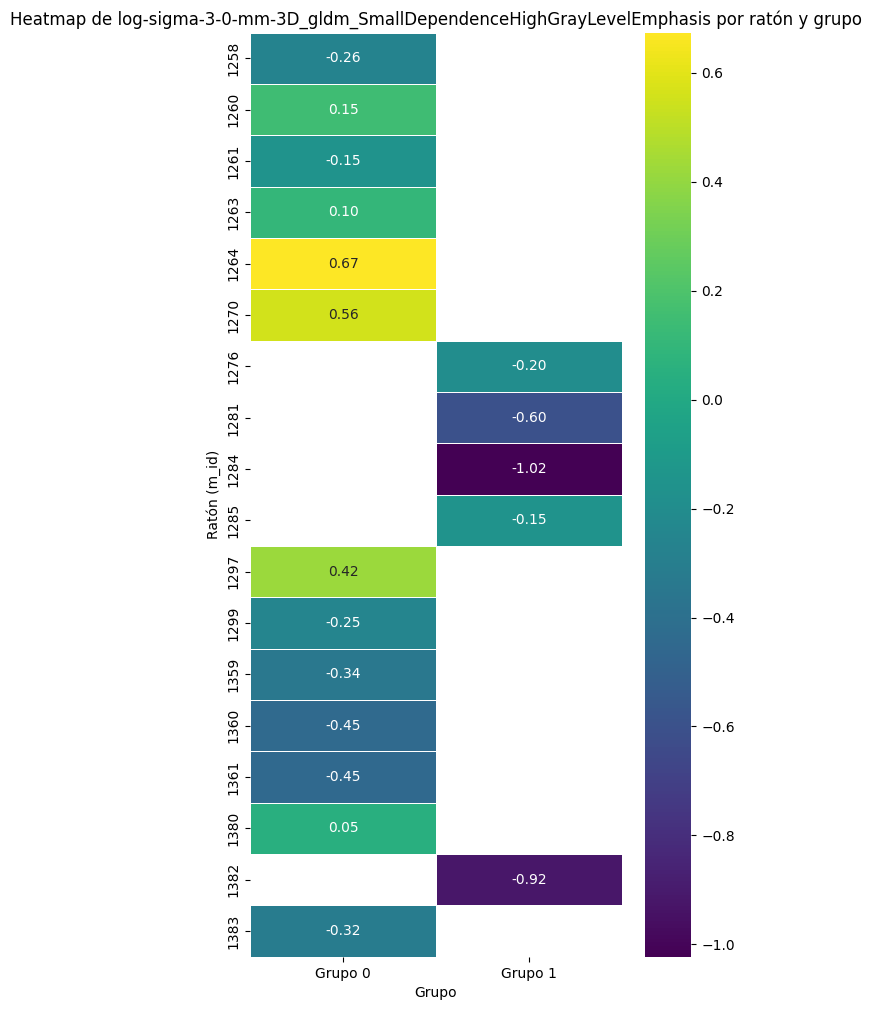

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config

# Cargar el dataset
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)  # Reemplaza con tu ruta de archivo

# Use standar scaler to normalize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop(columns=["m_id", "group_name"]))
df_scaled = pd.DataFrame(df_scaled, columns=df.columns[2:])
df_scaled["m_id"] = df["m_id"]
df_scaled["group_name"] = df["group_name"]

# Seleccionar la variable de interés
# feature = "log-sigma-3-0-mm-3D_ngtdm_Coarseness"
feature = "log-sigma-3-0-mm-3D_gldm_SmallDependenceHighGrayLevelEmphasis"

# Filtrar columnas necesarias
selected_columns = ["m_id", "group_name", feature]
df_filtered = df_scaled[selected_columns]

# Calcular la media de la variable por m_id y group_name
df_grouped = df_filtered.groupby(["m_id", "group_name"])[feature].mean().unstack()

# Crear el heatmap
plt.figure(figsize=(6, 12))
sns.heatmap(df_grouped, cmap="viridis", annot=True, fmt=".2f", linewidths=0.5)
plt.title(f"Heatmap de {feature} por ratón y grupo")
plt.xlabel("Grupo")
plt.ylabel("Ratón (m_id)")
plt.xticks(ticks=[0.5, 1.5], labels=["Grupo 0", "Grupo 1"], rotation=0)

plt.show()



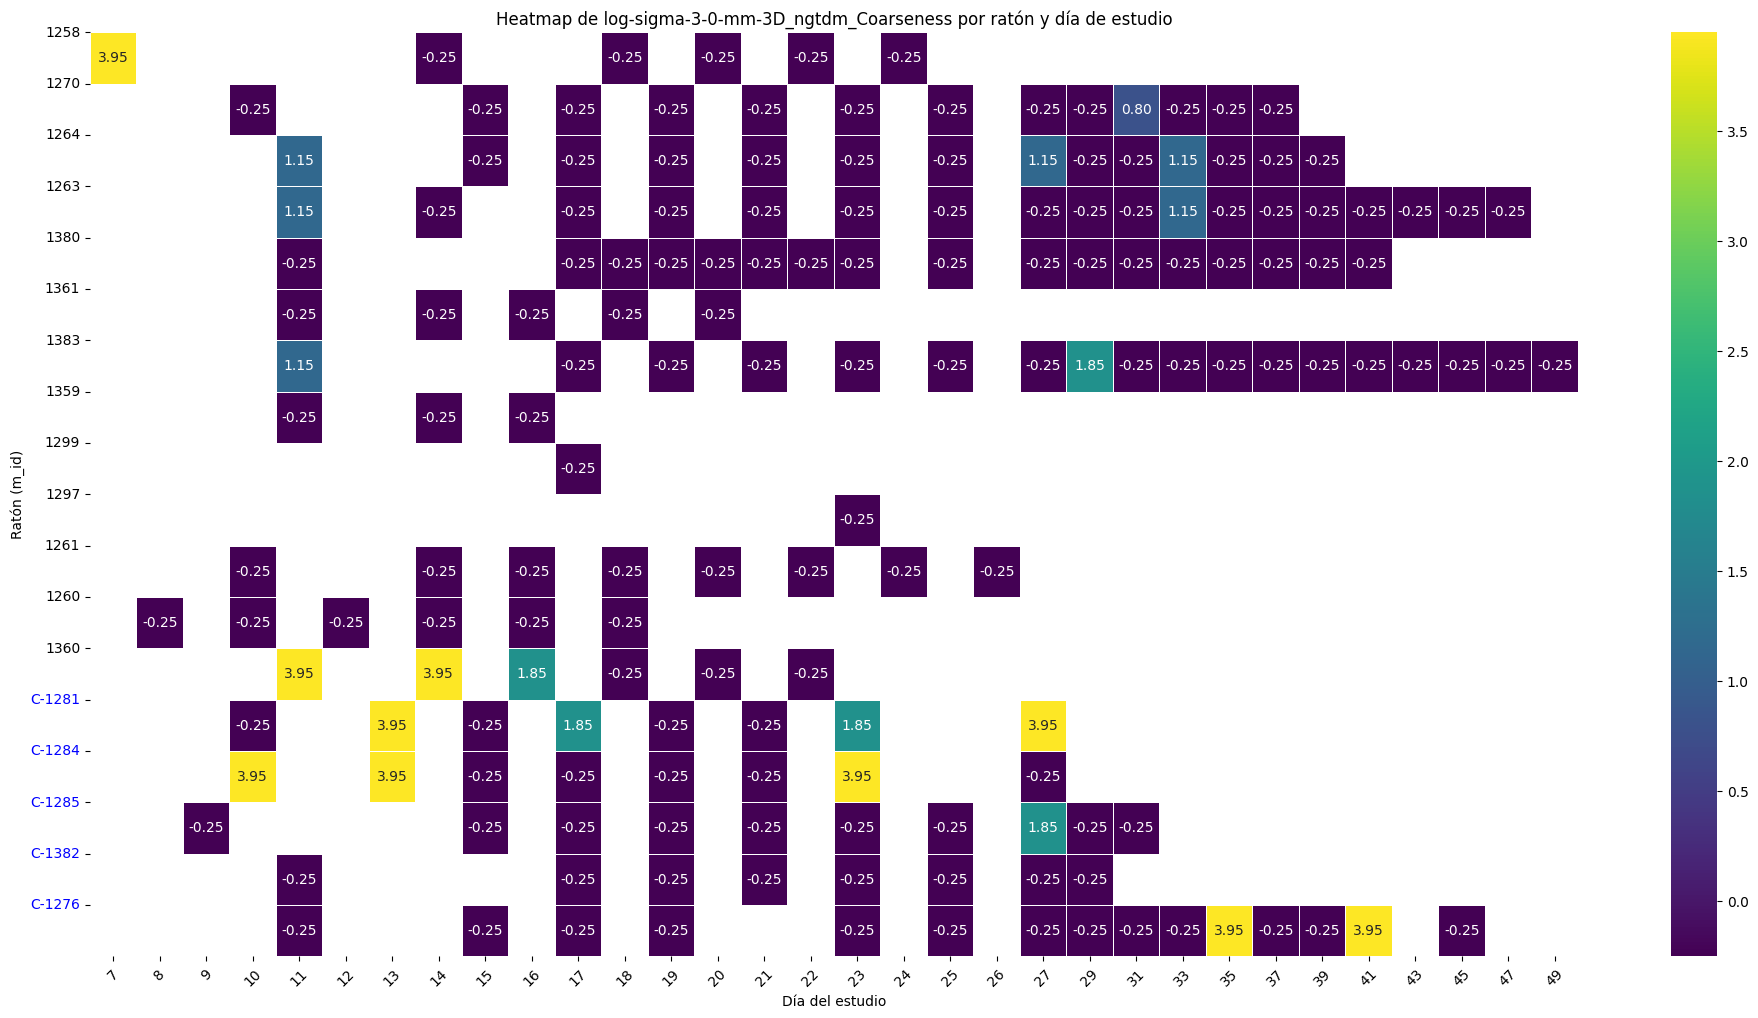

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import config

# Cargar el dataset
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)  # Reemplaza con tu ruta de archivo

features_csv = pd.read_csv("output/grouped_combinations_split_with_sampling/top_features/consistent_features.csv")
# selected_features = features_csv["feature"].tolist()

relapse_mice = df[df["group_name"] == 0]["m_id"].unique().tolist()
cured_mice = df[df["group_name"] == 1]["m_id"].unique().tolist()

# Seleccionar la variable de interés
feature = "log-sigma-3-0-mm-3D_ngtdm_Coarseness"

# Normalizar las características
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop(columns=["m_id", "group_name"]))
df_scaled = pd.DataFrame(df_scaled, columns=df.columns[2:])
df_scaled["m_id"] = df["m_id"]
df_scaled["group_name"] = df["group_name"]
df_scaled["day_of_study"] = df["day_of_study"]

# Filtrar columnas necesarias
selected_columns = ["m_id", "day_of_study", "group_name", feature]
df_filtered = df_scaled[selected_columns]

# Calcular la media de la variable por m_id y día de estudio
df_grouped = df_filtered.groupby(["m_id", "day_of_study"])[feature].mean().unstack()

# Ordenar por grupo (0 a la izquierda, 1 a la derecha)
mice_order = df_filtered.drop_duplicates(subset=["m_id", "group_name"]).sort_values("group_name")["m_id"]
df_grouped = df_grouped.loc[mice_order]

# Crear el heatmap
plt.figure(figsize=(24, 12))
sns.heatmap(df_grouped, cmap="viridis", annot=True, fmt=".2f", linewidths=0.5)
plt.title(f"Heatmap de {feature} por ratón y día de estudio")
plt.xlabel("Día del estudio")
plt.ylabel("Ratón (m_id)")
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Personalizar etiquetas del eje Y con color para los ratones curados
ax = plt.gca()
y_labels = [f"C-{m}" if m in cured_mice else str(m) for m in df_grouped.index]
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, rotation=0, fontsize=10)

# Cambiar el color de los m_id curados a azul
for tick_label, m in zip(ax.get_yticklabels(), df_grouped.index):
    if m in cured_mice:
        tick_label.set_color("blue")

plt.show()


KeyError: 'feature'

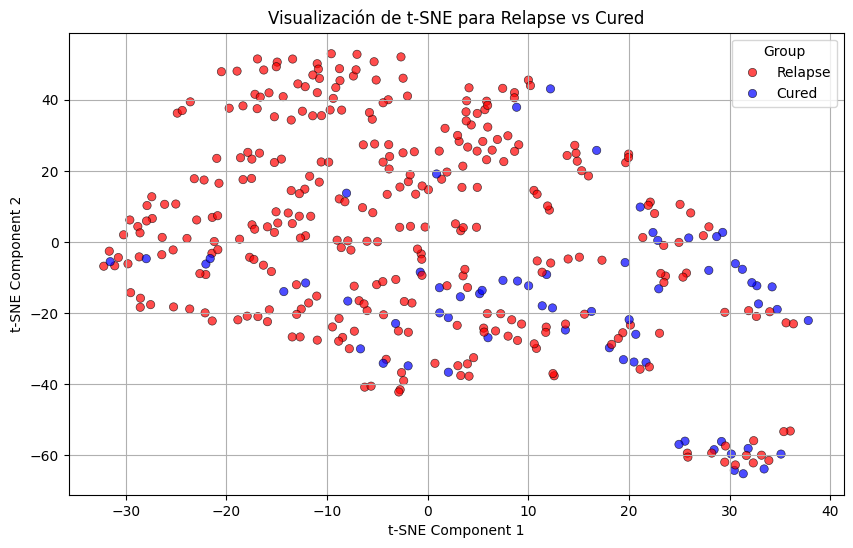

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import config

# Cargar el dataset
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)

# Cargar las características seleccionadas
features_csv = pd.read_csv("output/grouped_combinations_split_with_sampling/top_features/consistent_features.csv")
# selected_features = features_csv["feature"].tolist()
selected_features = significant_features

# Filtrar datos solo con las características seleccionadas y el grupo
df_selected = df[selected_features + ["m_id", "group_name"]]

# Normalizar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected[selected_features])

# Aplicar t-SNE (reducción de dimensionalidad a 2D)
tsne = TSNE(n_components=2, random_state=42, perplexity=10)  # Ajusta perplexity según la cantidad de datos
X_tsne = tsne.fit_transform(X_scaled)

# Crear DataFrame con los resultados de t-SNE
df_tsne = pd.DataFrame(X_tsne, columns=["TSNE_1", "TSNE_2"])
df_tsne["group_name"] = df_selected["group_name"]

# Graficar los resultados con Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tsne, x="TSNE_1", y="TSNE_2", hue=df_tsne["group_name"].map({0: "Relapse", 1: "Cured"}), 
                palette={"Relapse": "red", "Cured": "blue"}, alpha=0.7, edgecolor="k")

plt.title("Visualización de t-SNE para Relapse vs Cured")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Group")
plt.grid(True)
plt.show()



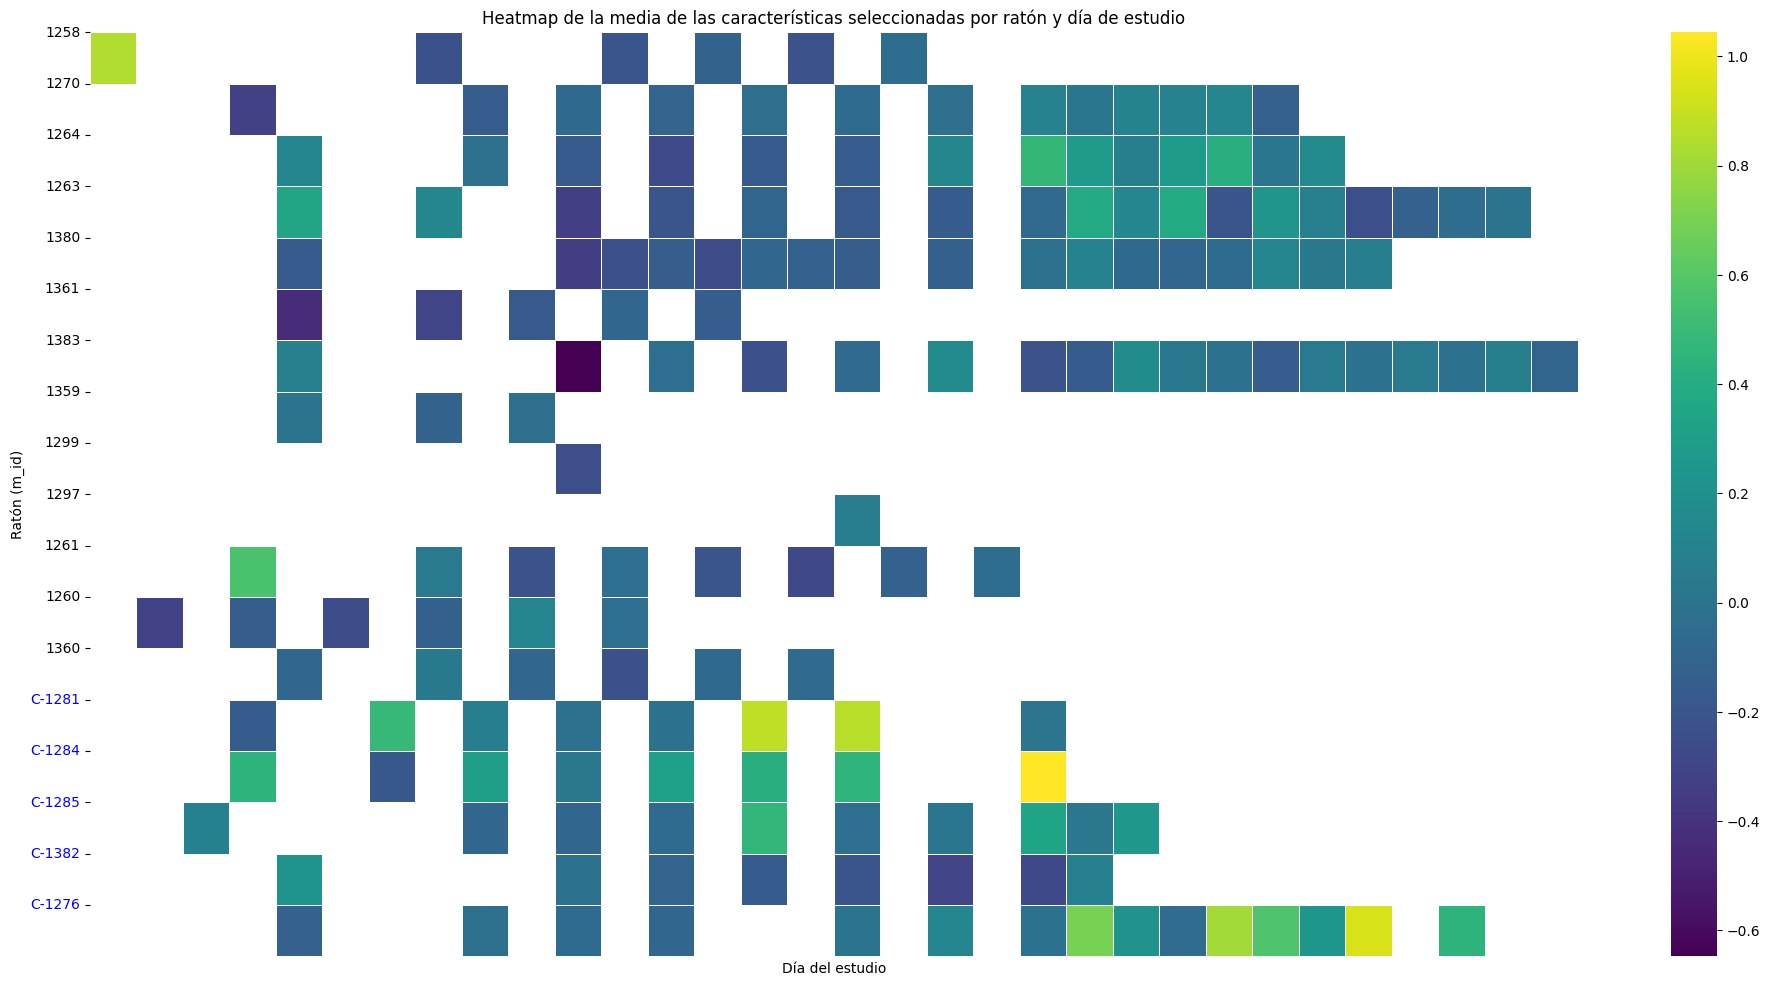

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# import config

# # Cargar el dataset
# df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)  # Reemplaza con tu ruta de archivo

# # Cargar las características seleccionadas
# features_csv = pd.read_csv("output/grouped_combinations_split_with_sampling/top_features/consistent_features.csv")
# selected_features = features_csv["feature"].tolist()

# # Obtener listas de ratones según grupo
# relapse_mice = df[df["group_name"] == 0]["m_id"].unique().tolist()
# cured_mice = df[df["group_name"] == 1]["m_id"].unique().tolist()

# # Normalizar las características seleccionadas
# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df[selected_features])
# df_scaled = pd.DataFrame(df_scaled, columns=selected_features)
# df_scaled["m_id"] = df["m_id"]
# df_scaled["group_name"] = df["group_name"]
# df_scaled["day_of_study"] = df["day_of_study"]

# # Calcular la media de las características seleccionadas por m_id y día de estudio
# df_scaled["feature_mean"] = df_scaled[selected_features].mean(axis=1)
# selected_columns = ["m_id", "day_of_study", "group_name", "feature_mean"]
# df_filtered = df_scaled[selected_columns]

# # Agrupar por m_id y día de estudio
# df_grouped = df_filtered.groupby(["m_id", "day_of_study"])["feature_mean"].mean().unstack()

# # Ordenar por grupo (0 a la izquierda, 1 a la derecha)
# mice_order = df_filtered.drop_duplicates(subset=["m_id", "group_name"]).sort_values("group_name")["m_id"]
# df_grouped = df_grouped.loc[mice_order]

# # Crear el heatmap
# plt.figure(figsize=(24, 12))
# sns.heatmap(df_grouped, cmap="viridis", annot=False, fmt=".2f", linewidths=0.5)
# plt.title(f"Heatmap de la media de las características seleccionadas por ratón y día de estudio")
# plt.xlabel("Día del estudio")
# plt.ylabel("Ratón (m_id)")
# plt.xticks([])
# plt.yticks(rotation=0)

# # Personalizar etiquetas del eje Y con color para los ratones curados
# ax = plt.gca()
# y_labels = [f"C-{m}" if m in cured_mice else str(m) for m in df_grouped.index]
# ax.set_yticks(range(len(y_labels)))
# ax.set_yticklabels(y_labels, rotation=0, fontsize=10)

# # Cambiar el color de los m_id curados a azul
# for tick_label, m in zip(ax.get_yticklabels(), df_grouped.index):
#     if m in cured_mice:
#         tick_label.set_color("blue")

# plt.show()


In [ ]:
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES_NO_FILTERS)  # Reemplaza con tu ruta de archivo

# Seleccionar la variable de interés
feature = "original_ngtdm_Coarseness"

# Filtrar columnas necesarias
selected_columns = ["m_id", "day_of_study", "group_name", feature]

# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop(columns=["m_id", "group_name"]))
df_scaled = pd.DataFrame(df_scaled, columns=df.columns[2:])
df_scaled["m_id"] = df["m_id"]
df_scaled["group_name"] = df["group_name"]

# Filter and get only m_id == 1258
df_filtered = df_scaled[selected_columns]
df_filtered = df_filtered[df_filtered["m_id"] == 1258]

df_filtered


,m_id,day_of_study,group_name,original_ngtdm_Coarseness
0,1258,-1.129080,0,-0.187698
1,1258,-0.722760,0,-0.187698
2,1258,-0.519600,0,-0.187698
3,1258,-0.316440,0,-0.187698
4,1258,-0.113280,0,-0.187698
5,1258,-0.113280,0,-0.187698
6,1258,-0.113280,0,-0.187698
7,1258,-1.840139,0,5.327721
8,1258,-1.840139,0,-0.187688


C:\Users\xavie\AppData\Local\Temp\ipykernel_23760\270110933.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["group_name"] = df_filtered["group_name"].astype(int)


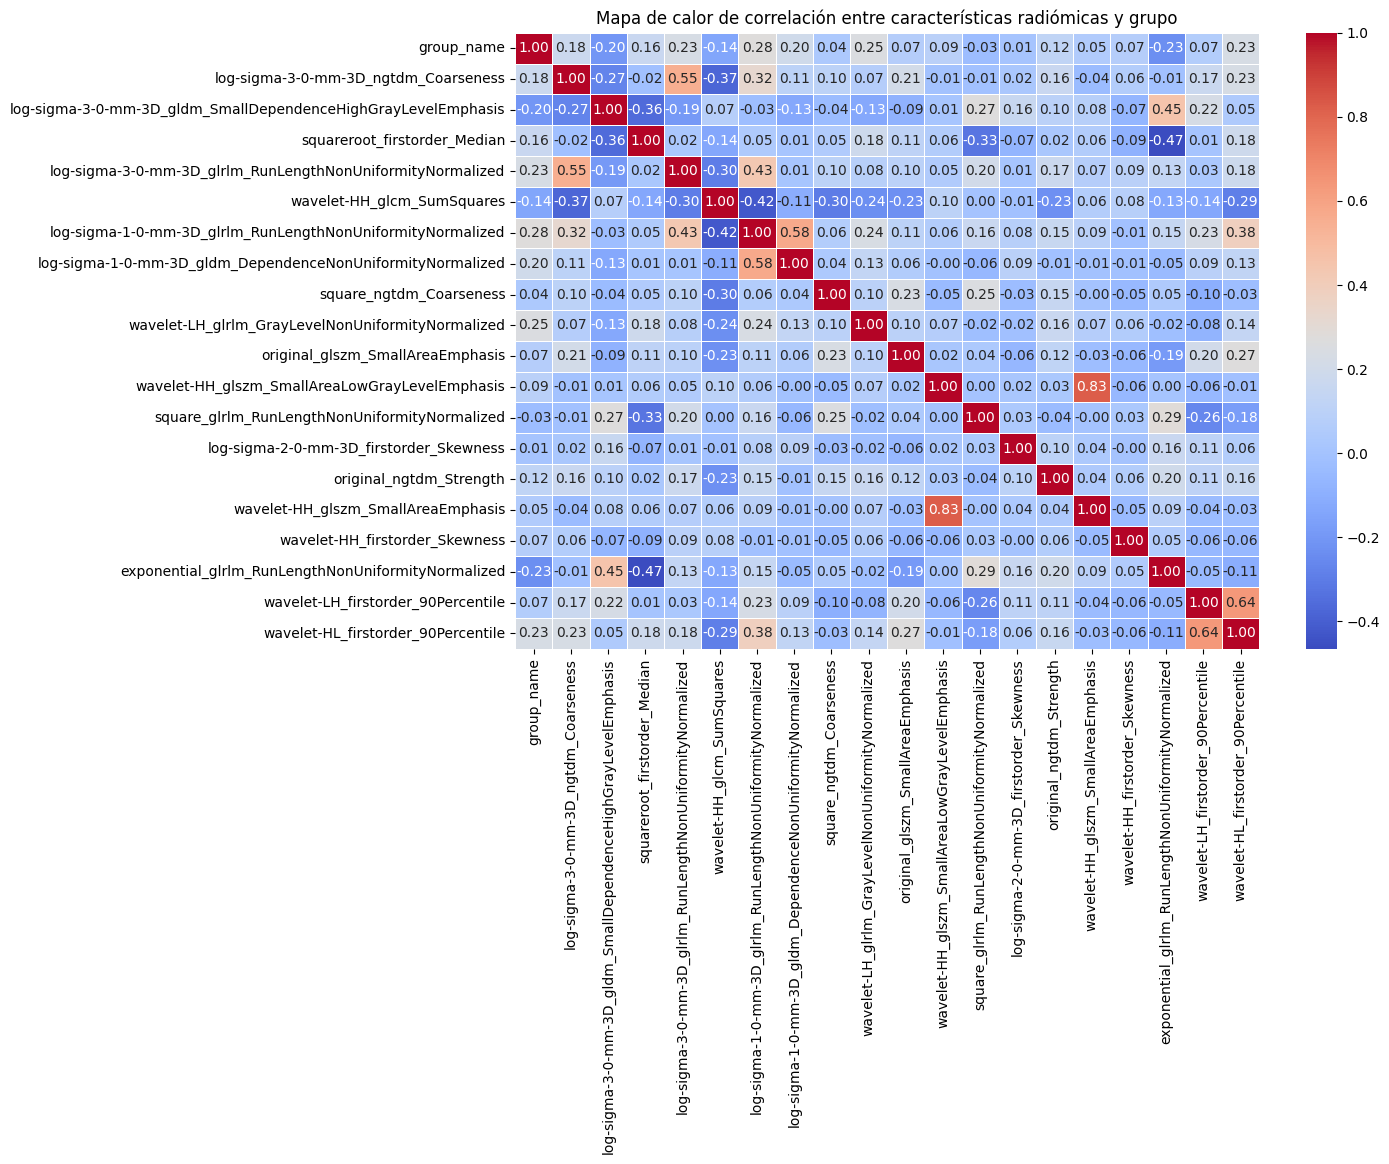

Correlación de las características con el grupo (Curado/Recaída):
log-sigma-1-0-mm-3D_glrlm_RunLengthNonUniformityNormalized       0.278213
wavelet-LH_glrlm_GrayLevelNonUniformityNormalized                0.252930
log-sigma-3-0-mm-3D_glrlm_RunLengthNonUniformityNormalized       0.232010
wavelet-HL_firstorder_90Percentile                               0.228765
log-sigma-1-0-mm-3D_gldm_DependenceNonUniformityNormalized       0.196874
log-sigma-3-0-mm-3D_ngtdm_Coarseness                             0.175420
squareroot_firstorder_Median                                     0.160415
original_ngtdm_Strength                                          0.119345
wavelet-HH_glszm_SmallAreaLowGrayLevelEmphasis                   0.090524
wavelet-HH_firstorder_Skewness                                   0.070204
original_glszm_SmallAreaEmphasis                                 0.067569
wavelet-LH_firstorder_90Percentile                               0.065001
wavelet-HH_glszm_SmallAreaEmphasis            

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config

# Cargar el dataset
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)  # Reemplaza con tu ruta de archivo

# Cargar las características seleccionadas
features_csv = pd.read_csv("output/grouped_combinations_split_with_sampling/top_features/consistent_features.csv")
selected_features = features_csv["feature"].tolist()

# Filtrar solo las columnas de interés (incluyendo group_name)
selected_columns = ["group_name"] + selected_features
df_filtered = df[selected_columns]

# Convertir 'group_name' a numérico si no lo está (suponiendo 0 = Curado, 1 = Recaída)
df_filtered["group_name"] = df_filtered["group_name"].astype(int)

# Calcular la matriz de correlación
correlation_matrix = df_filtered.corr()

# Graficar el mapa de calor de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Mapa de calor de correlación entre características radiómicas y grupo")
plt.show()

# Extraer la correlación de 'group_name' con las demás características
correlation_with_group = correlation_matrix["group_name"].drop("group_name").sort_values(ascending=False)

# Mostrar la correlación ordenada con el grupo
print("Correlación de las características con el grupo (Curado/Recaída):")
print(correlation_with_group)


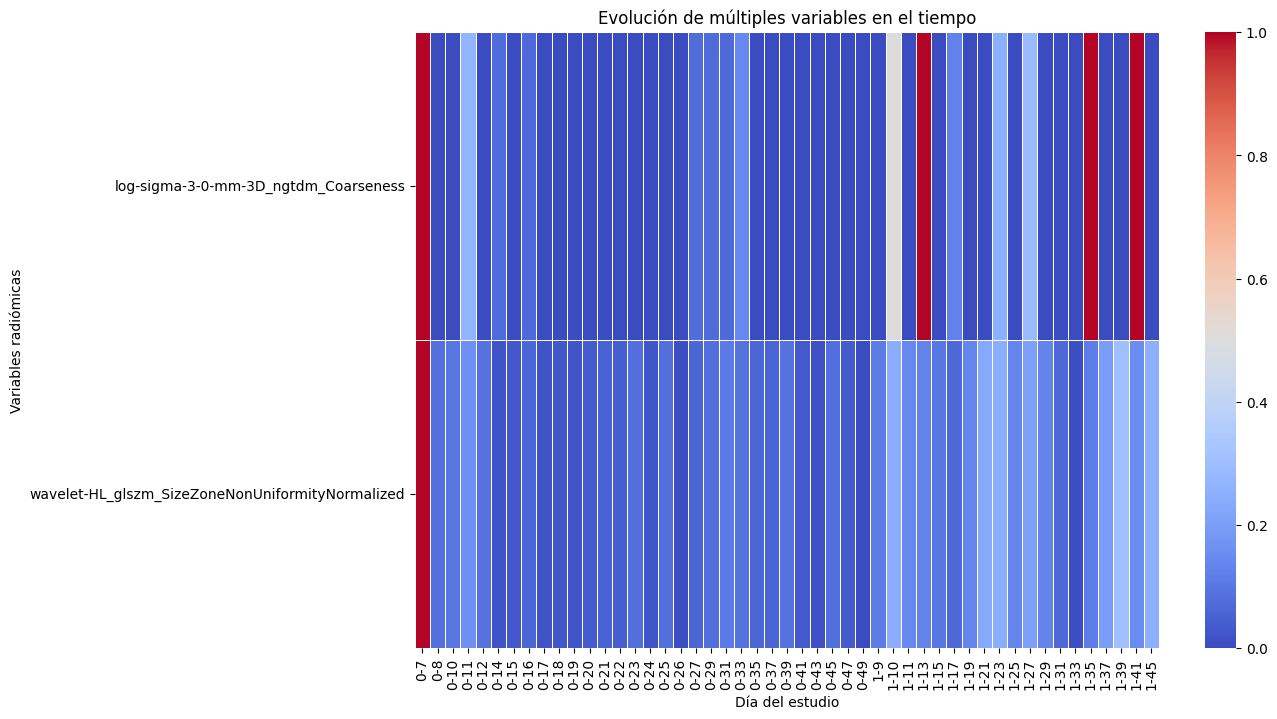

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config

# Cargar datos
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)

# Seleccionar variables de interés
selected_features = ["log-sigma-3-0-mm-3D_ngtdm_Coarseness", 
                     "wavelet-HL_glszm_SizeZoneNonUniformityNormalized"]

# Filtrar dataset
df_filtered = df.groupby(["group_name", "day_of_study"])[selected_features].mean()

# Normalizar para ver patrones más claros
df_normalized = df_filtered.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Graficar heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_normalized.T, cmap="coolwarm", linewidths=0.5)
plt.title("Evolución de múltiples variables en el tiempo")
plt.xlabel("Día del estudio")
plt.ylabel("Variables radiómicas")
plt.show()

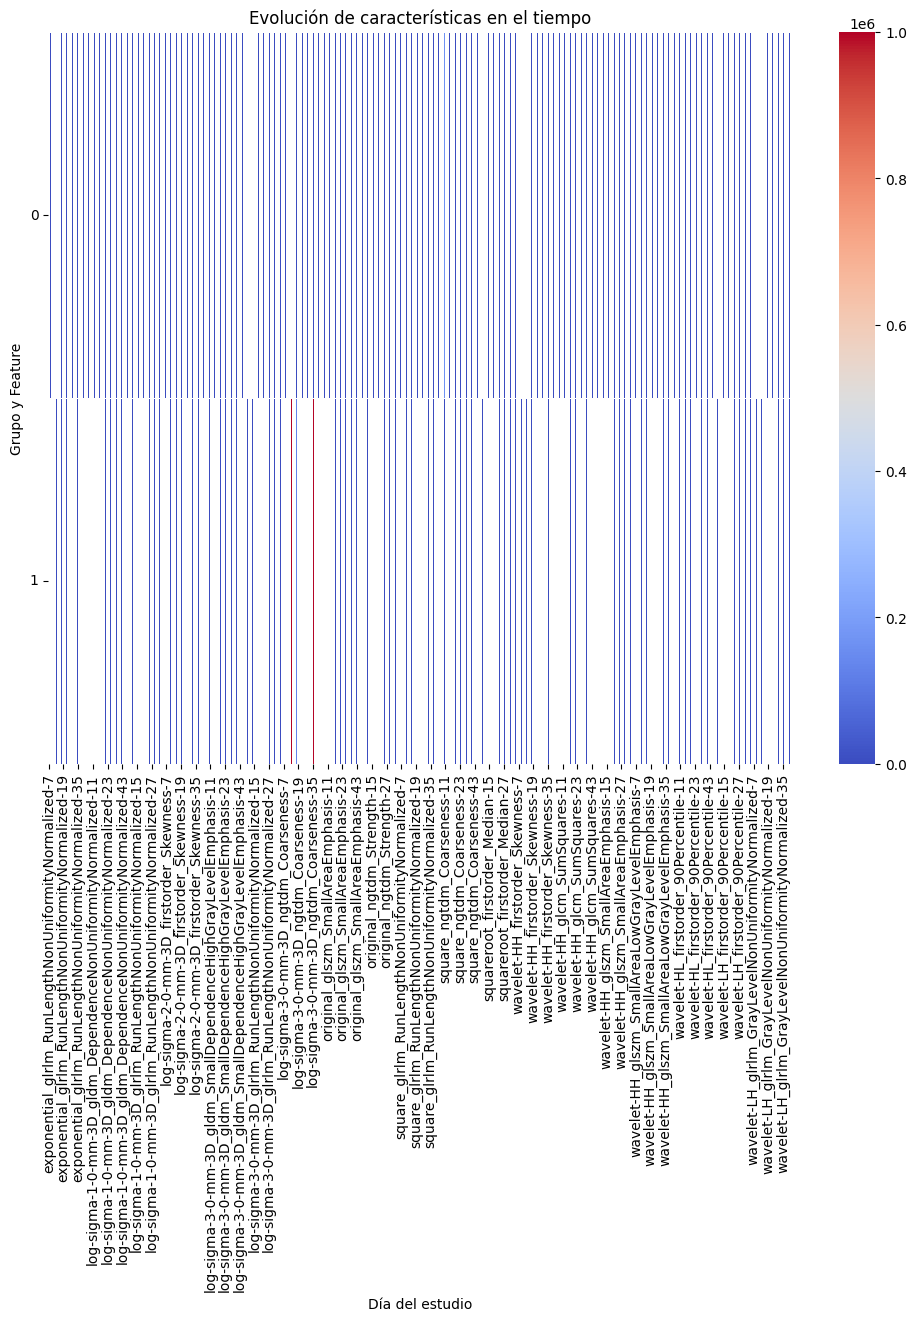

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config

# Cargar el dataset
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)  # Reemplaza con tu ruta de archivo

# Cargar las características seleccionadas
features_csv = pd.read_csv("output/grouped_combinations_split_with_sampling/top_features/consistent_features.csv")
selected_features = features_csv["feature"].tolist()

# Filtrar solo las columnas necesarias
selected_columns = ["group_name", "day_of_study"] + selected_features
df_filtered = df[selected_columns]

# Agrupar por grupo y día de estudio, tomando la media
df_grouped = df_filtered.groupby(["group_name", "day_of_study"]).mean().reset_index()

# Pivotar para heatmap
heatmap_data = df_grouped.pivot_table(index=["group_name"], columns="day_of_study", values=selected_features)

# Crear el heatmap
plt.figure(figsize=(12, len(selected_features) * 0.5))  # Ajusta el tamaño según el número de features
sns.heatmap(heatmap_data, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Evolución de características en el tiempo")
plt.xlabel("Día del estudio")
plt.ylabel("Grupo y Feature")
plt.yticks(rotation=0)
plt.show()


KeyError: 'group_name'

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config

# Cargar datos
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)[["group_name", "day_of_study", "log-sigma-3-0-mm-3D_ngtdm_Coarseness"]]
print(df.head())
df = df.groupby(["group_name", "day_of_study"])[feature].mean().unstack(0)
print(df.head())

   group_name  day_of_study  log-sigma-3-0-mm-3D_ngtdm_Coarseness
0           0            14                              0.387097
1           0            18                              0.046881
2           0            20                              0.051596
3           0            22                              0.032059
4           0            24                              0.027498
group_name                 0              1
day_of_study                               
7             1000000.000000            NaN
8                   0.118397            NaN
9                        NaN       0.136965
10                  0.158269  500000.193899
11             266666.784665       1.012978


day_of_study         7         8         9              10             11  \
group_name                                                                  
0             1000000.0  0.118397       NaN       0.158269  266666.784665   
1                   NaN       NaN  0.136965  500000.193899       1.012978   

day_of_study        12         13           14        15            16  ...  \
group_name                                                              ...   
0             0.066707        NaN  71428.68659  0.105695  66666.741573  ...   
1                  NaN  1000000.0          NaN  0.367309           NaN  ...   

day_of_study            31             33              35       37        39  \
group_name                                                                     
0             66666.875299  142857.244711        0.110757  0.10295  0.127321   
1                 0.104830       0.123603  1000000.000000  0.17053  0.184903   

day_of_study              41        43        45     

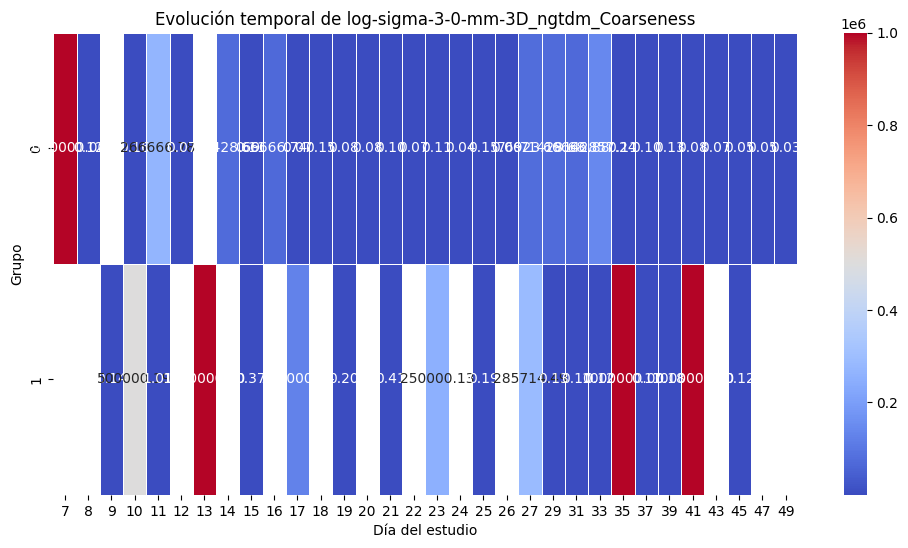

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config

# Cargar datos
df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)

# Seleccionar variable de interés
feature = "log-sigma-3-0-mm-3D_ngtdm_Coarseness"  # Cambia a la variable que te interese

# Agrupar por grupo y día de estudio, tomando la media
df_grouped = df.groupby(["group_name", "day_of_study"])[feature].mean().unstack()
print(df_grouped.head())

# Crear el heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_grouped, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title(f"Evolución temporal de {feature}")
plt.xlabel("Día del estudio")
plt.ylabel("Grupo")
plt.show()
